In [3]:
print("Audio Classification Project Started")

Audio Classification Project Started


import torch
print(torch.__version__)

import torchvision
print(torchvision.__version__)

import torchaudio
print(torchaudio.__version__)

In [4]:
import librosa

print(librosa.__version__)

0.11.0


import sys

print(sys.executable)

In [5]:
# Audio Classification Using CNN

## Dataset: Speech Commands v0.02

### Step 1: Dataset Exploration

In [6]:
import os
import glob
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from IPython.display import Audio, display

In [7]:
DATASET_PATH = "../data/speech_commands_v0.02"

print(DATASET_PATH)

../data/speech_commands_v0.02


In [8]:
print(os.path.exists(DATASET_PATH))

True


In [9]:
class_names = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
    and not folder.startswith("_")
])

print(class_names)

['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [10]:
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 35


In [11]:
class_counts = {}

for cls in class_names:

    wav_files = glob.glob(
        os.path.join(DATASET_PATH, cls, "*.wav")
    )

    class_counts[cls] = len(wav_files)

class_counts

{'backward': 1664,
 'bed': 2014,
 'bird': 2064,
 'cat': 2031,
 'dog': 2128,
 'down': 3917,
 'eight': 3787,
 'five': 4052,
 'follow': 1579,
 'forward': 1557,
 'four': 3728,
 'go': 3880,
 'happy': 2054,
 'house': 2113,
 'learn': 1575,
 'left': 3801,
 'marvin': 2100,
 'nine': 3934,
 'no': 3941,
 'off': 3745,
 'on': 3845,
 'one': 3890,
 'right': 3778,
 'seven': 3998,
 'sheila': 2022,
 'six': 3860,
 'stop': 3872,
 'three': 3727,
 'tree': 1759,
 'two': 3880,
 'up': 3723,
 'visual': 1592,
 'wow': 2123,
 'yes': 4044,
 'zero': 4052}

In [12]:
df_classes = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Samples"]
)

df_classes

,Class,Number of Samples
0,backward,1664
1,bed,2014
2,bird,2064
3,cat,2031
4,dog,2128
5,down,3917
6,eight,3787
7,five,4052
8,follow,1579
9,forward,1557


In [13]:
total_files = df_classes["Number of Samples"].sum()

print("Total audio files:", total_files)

Total audio files: 105829


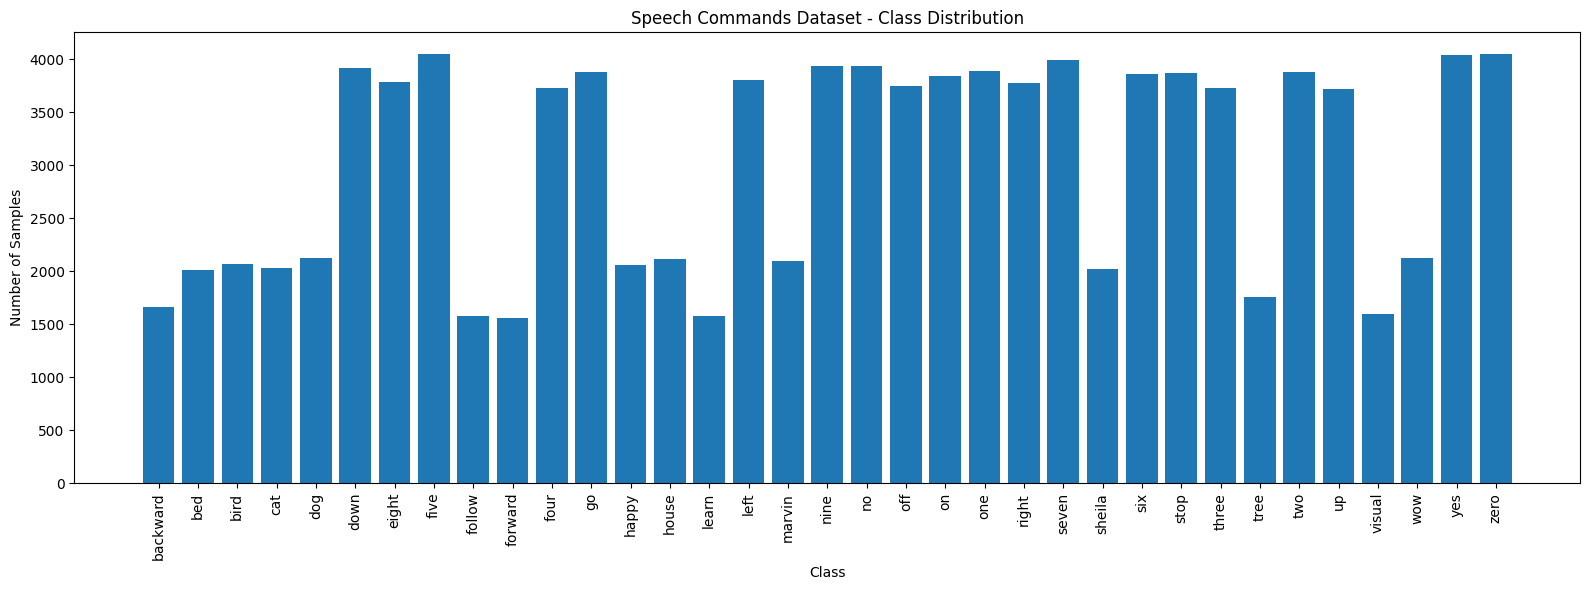

In [14]:
plt.figure(figsize=(16,6))

plt.bar(
    df_classes["Class"],
    df_classes["Number of Samples"]
)

plt.xticks(rotation=90)

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.title("Speech Commands Dataset - Class Distribution")

plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png")
plt.show()


In [15]:
import os
import librosa

# Get first class
first_class = class_names[0]

# Get first audio file
first_audio = os.path.join(
    DATASET_PATH,
    first_class,
    os.listdir(os.path.join(DATASET_PATH, first_class))[0]
)

print(first_audio)

../data/speech_commands_v0.02\backward\0165e0e8_nohash_0.wav


In [16]:
audio, sr = librosa.load(first_audio, sr=None)

print("Sample Rate:", sr)

Sample Rate: 16000


In [17]:
duration = librosa.get_duration(y=audio, sr=sr)

print("Duration:", duration)

Duration: 1.0


In [18]:
import glob

all_audio_files = glob.glob(
    os.path.join(DATASET_PATH, "*", "*.wav")
)























print("Total audio files:", len(all_audio_files))

Total audio files: 105835


In [19]:
total_seconds = 0

for file in all_audio_files:

    y, sr = librosa.load(file, sr=None)

    total_seconds += librosa.get_duration(y=y, sr=sr)

print(total_seconds)

104210.27399999984


In [20]:
minutes = total_seconds / 60

hours = minutes / 60

print("Total Seconds :", total_seconds)

print("Total Minutes :", minutes)

print("Total Hours :", hours)

Total Seconds : 104210.27399999984
Total Minutes : 1736.8378999999975
Total Hours : 28.94729833333329


In [21]:
summary = pd.DataFrame({

    "Property":[
        "Dataset",
        "Classes",
        "Total Samples",
        "Sample Rate",
        "Duration per Clip",
        "Total Duration (hours)"
    ],

    "Value":[
        "Speech Commands v0.02",
        num_classes,
        total_files,
        f"{sr} Hz",
        "1 second",
        round(hours,2)
    ]
})

summary

,Property,Value
0,Dataset,Speech Commands v0.02
1,Classes,35
2,Total Samples,105829
3,Sample Rate,16000 Hz
4,Duration per Clip,1 second
5,Total Duration (hours),28.95


In [22]:
summary.to_csv(
    "../outputs/figures/dataset_summary.csv",
    index=False
)

In [23]:
def visualize_audio(file_path, class_name):
    """
    Display audio player, waveform and log-mel spectrogram
    for one audio file.
    """

    # Load audio
    y, sr = librosa.load(file_path, sr=None)

    print("=" * 60)
    print(f"Class       : {class_name}")
    print(f"File        : {os.path.basename(file_path)}")
    print(f"Sample Rate : {sr} Hz")
    print(f"Duration    : {librosa.get_duration(y=y, sr=sr):.2f} sec")

    # Audio player
    display(Audio(y, rate=sr))

    # Create figure
    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)

    librosa.display.waveshow(y, sr=sr)

    plt.title("Waveform")

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=64
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.subplot(1,2,2)

    librosa.display.specshow(
        log_mel,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")

    plt.title("Log Mel Spectrogram")

    plt.tight_layout()

    save_path = os.path.join(
        "../outputs/figures",
        f"{class_name}.png"
    )

    plt.savefig(save_path)

    plt.show()

    plt.close()

Class       : backward
File        : 0165e0e8_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


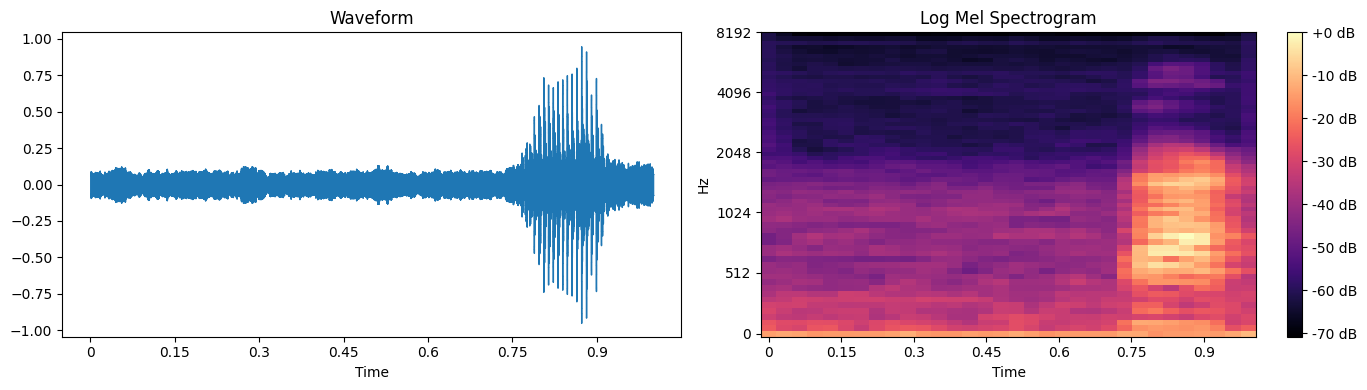

In [24]:
first_class = class_names[0]

sample_file = glob.glob(
    os.path.join(DATASET_PATH, first_class, "*.wav")
)[0]

visualize_audio(sample_file, first_class)

Class       : backward
File        : 0165e0e8_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


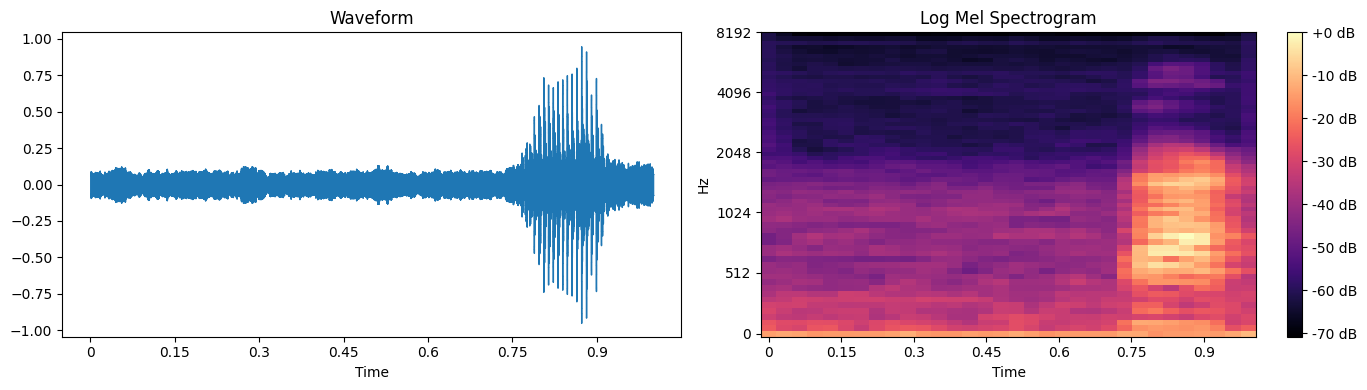

Class       : bed
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


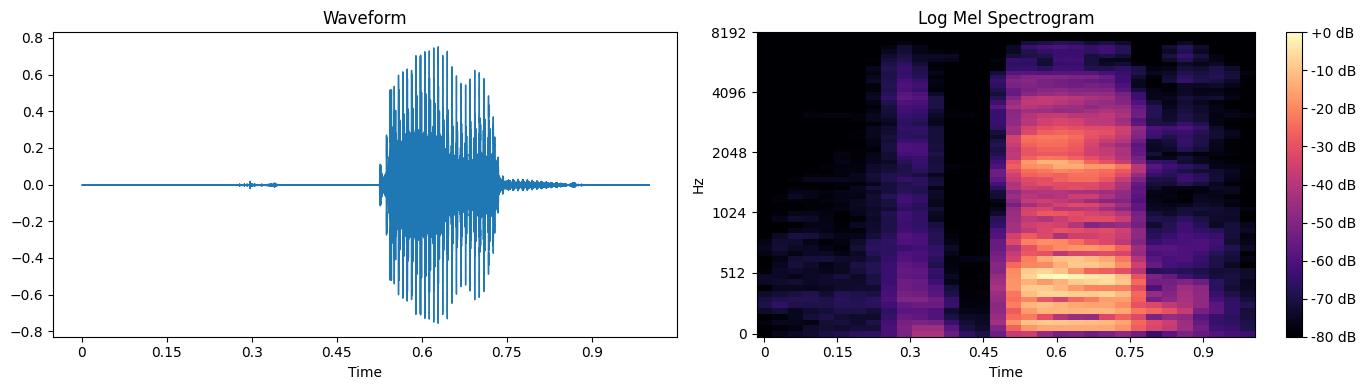

Class       : bird
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.60 sec


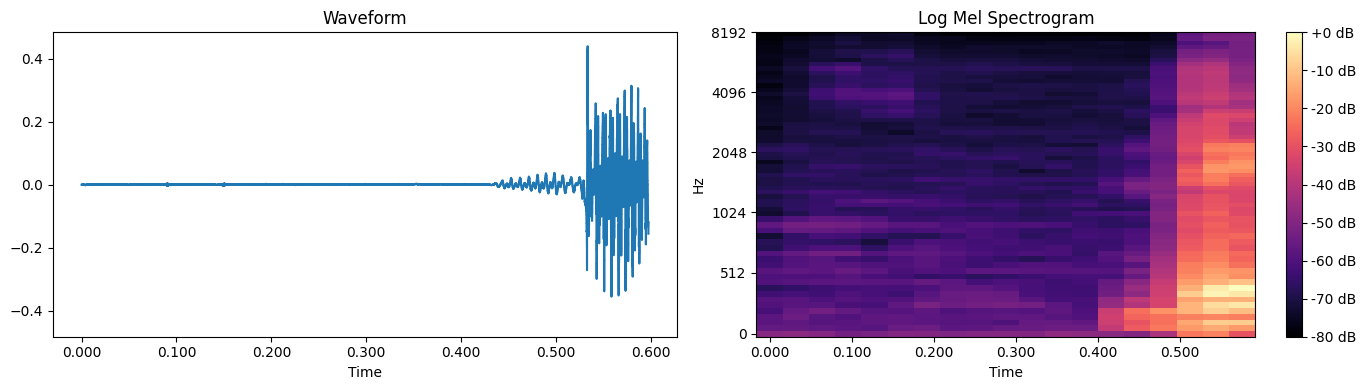

Class       : cat
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


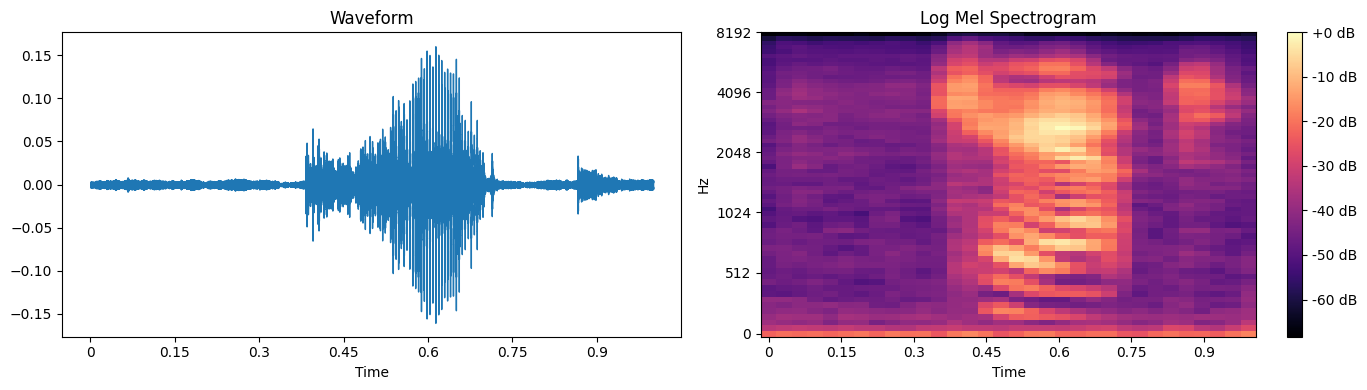

Class       : dog
File        : 00b01445_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


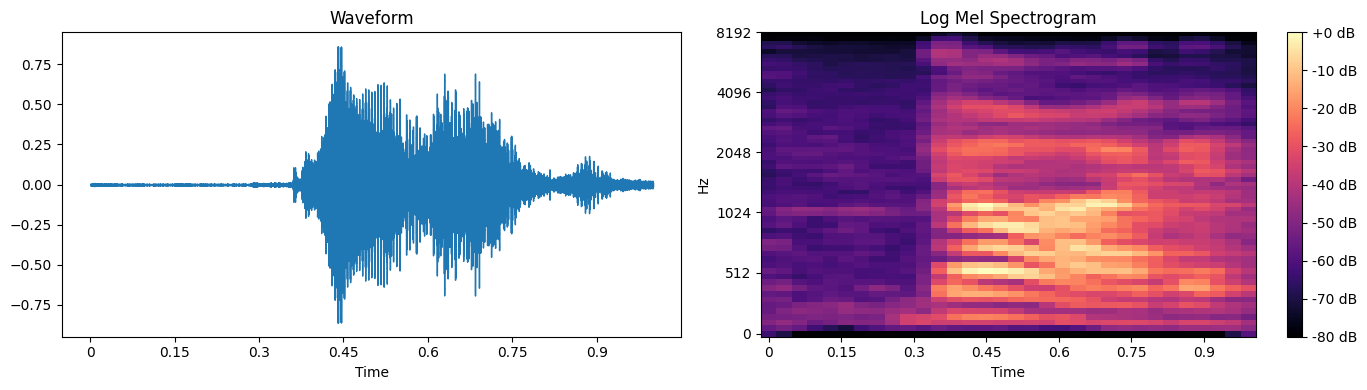

Class       : down
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


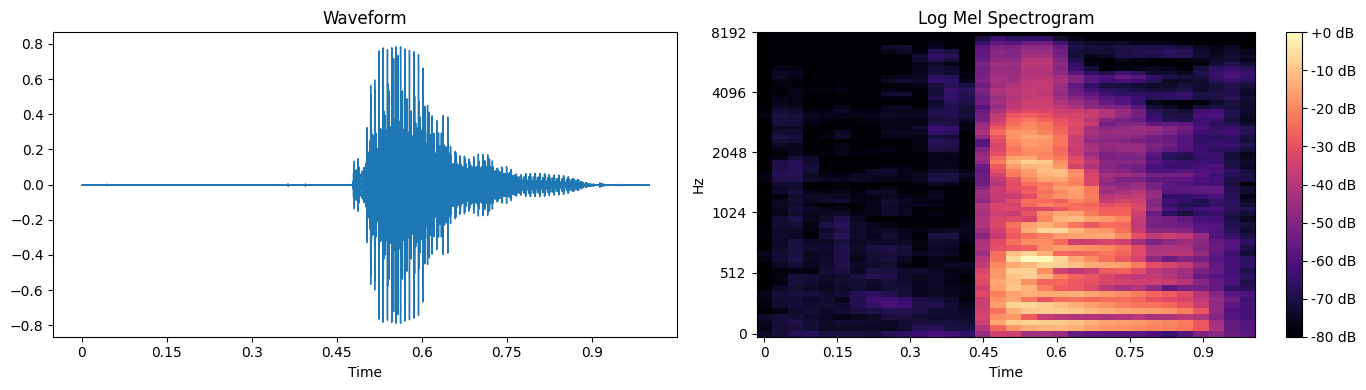

Class       : eight
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


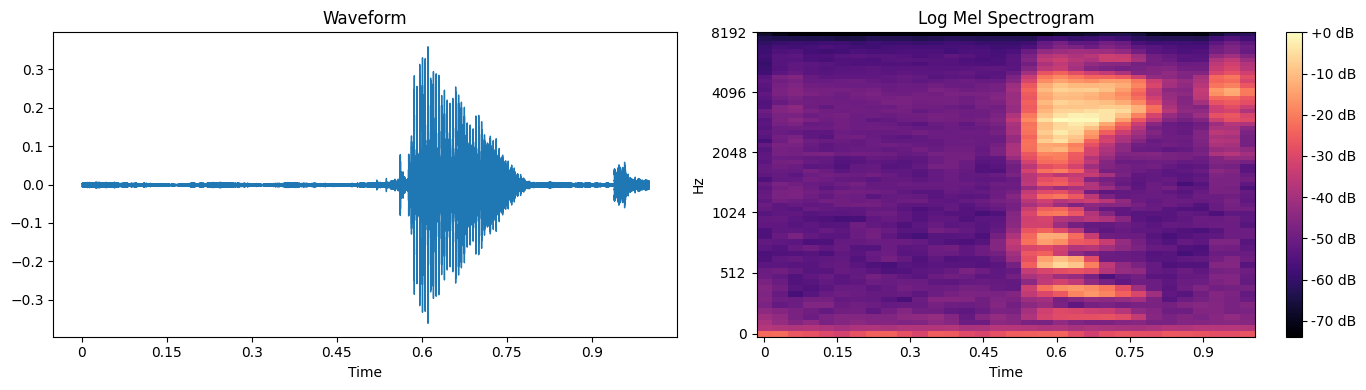

Class       : five
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


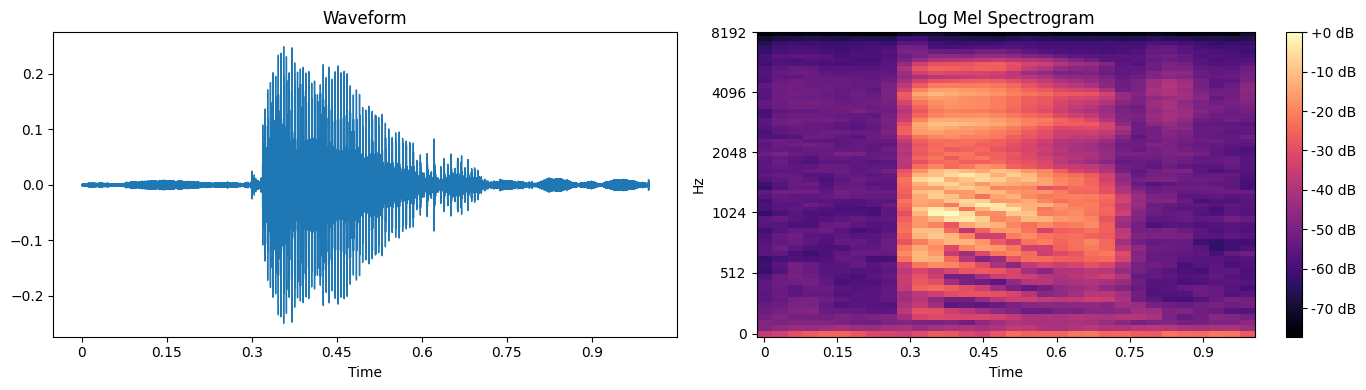

Class       : follow
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.77 sec


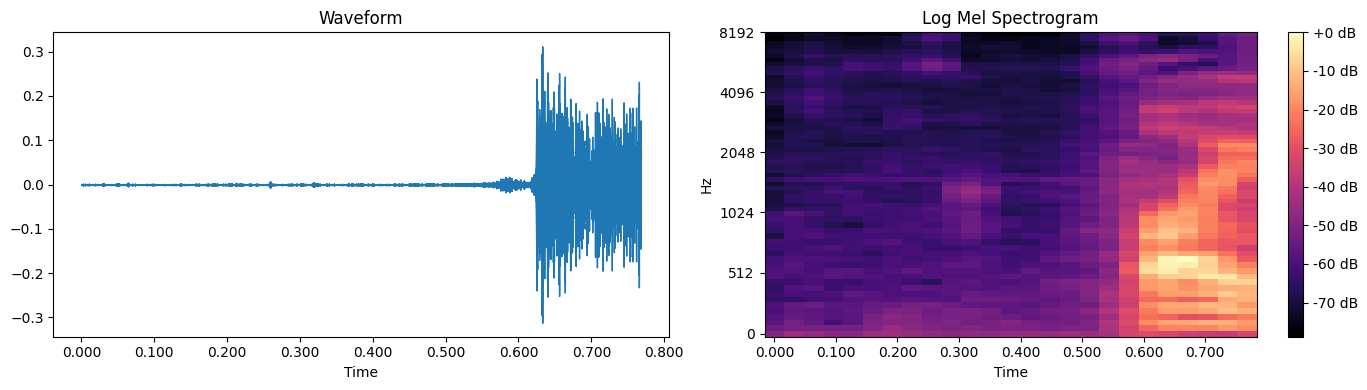

Class       : forward
File        : 012187a4_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.64 sec


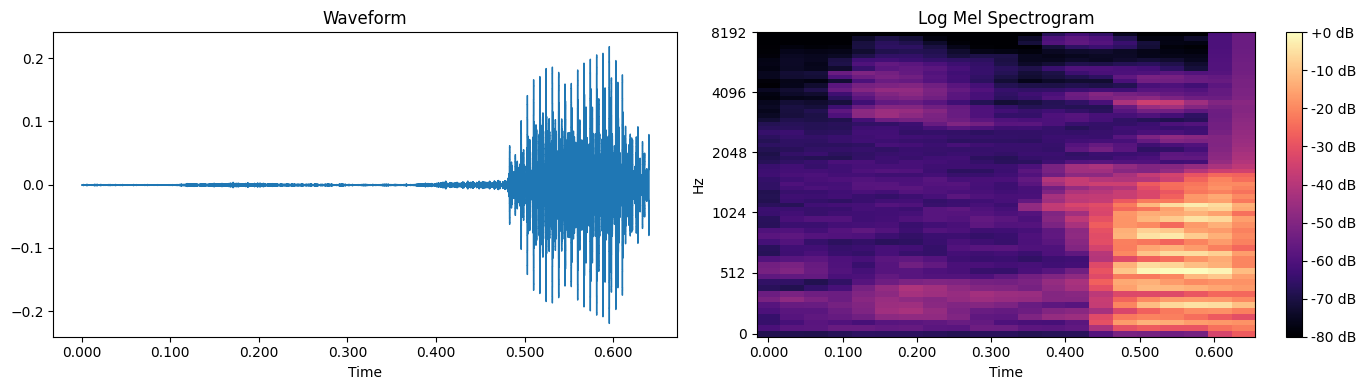

Class       : four
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.98 sec


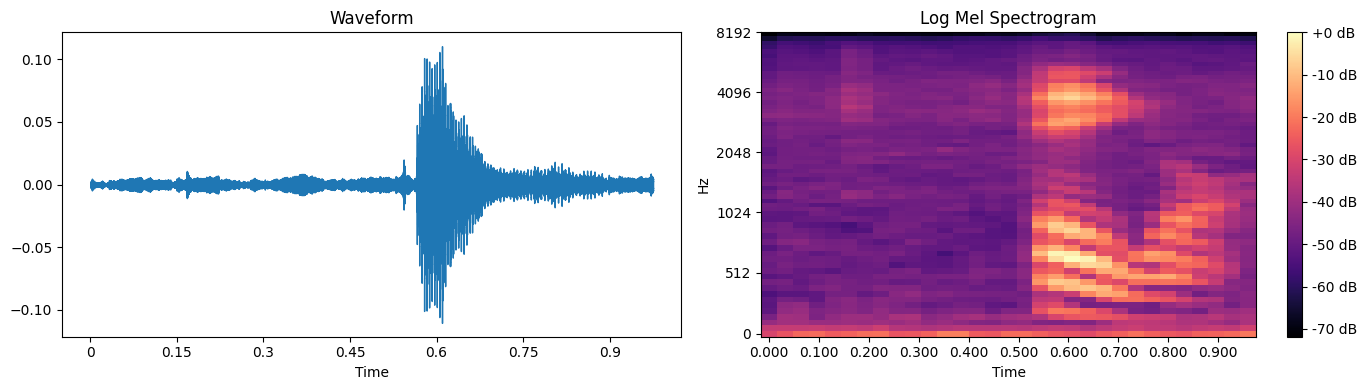

Class       : go
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.74 sec


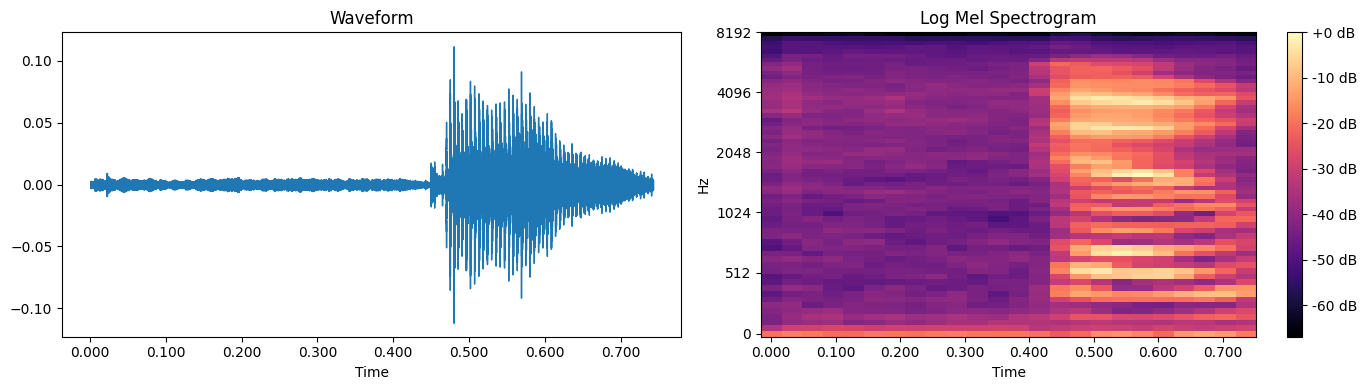

Class       : happy
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.98 sec


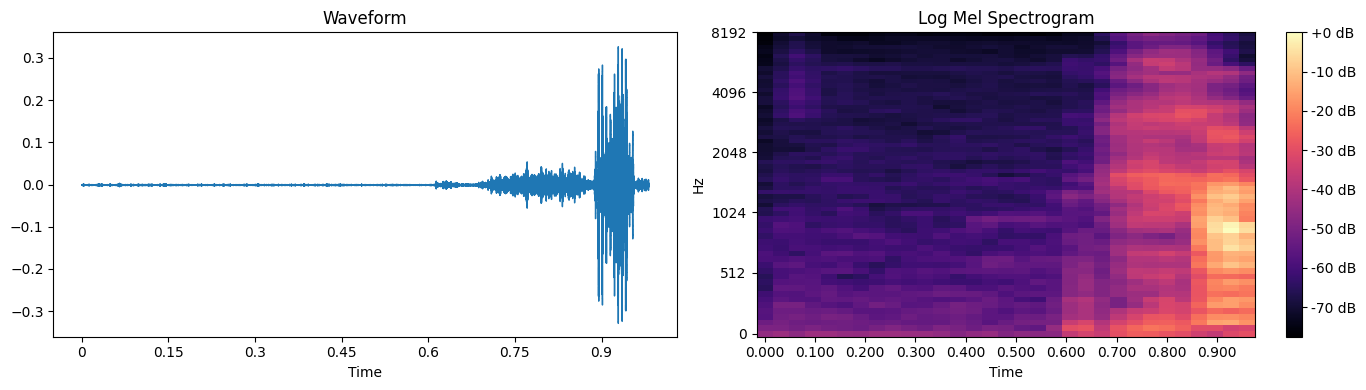

Class       : house
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.90 sec


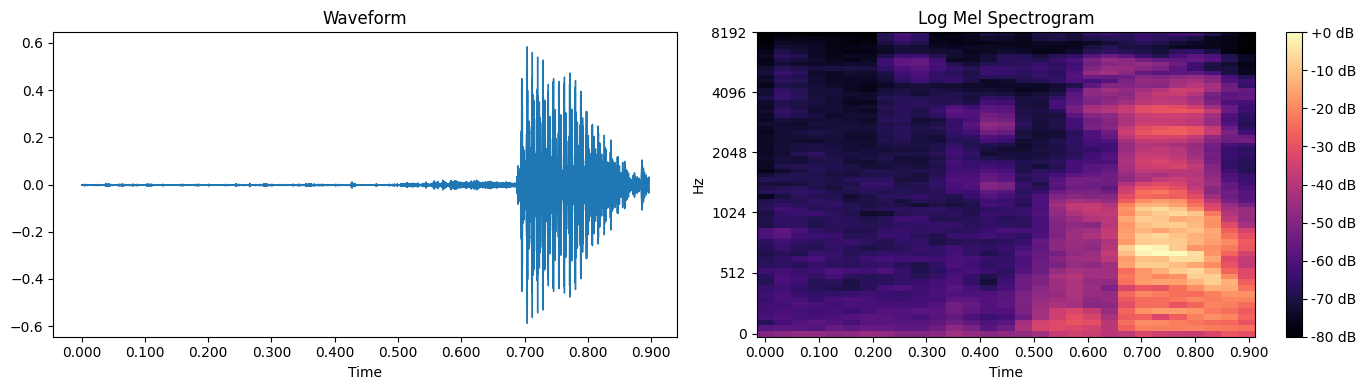

Class       : learn
File        : 00761705_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.51 sec


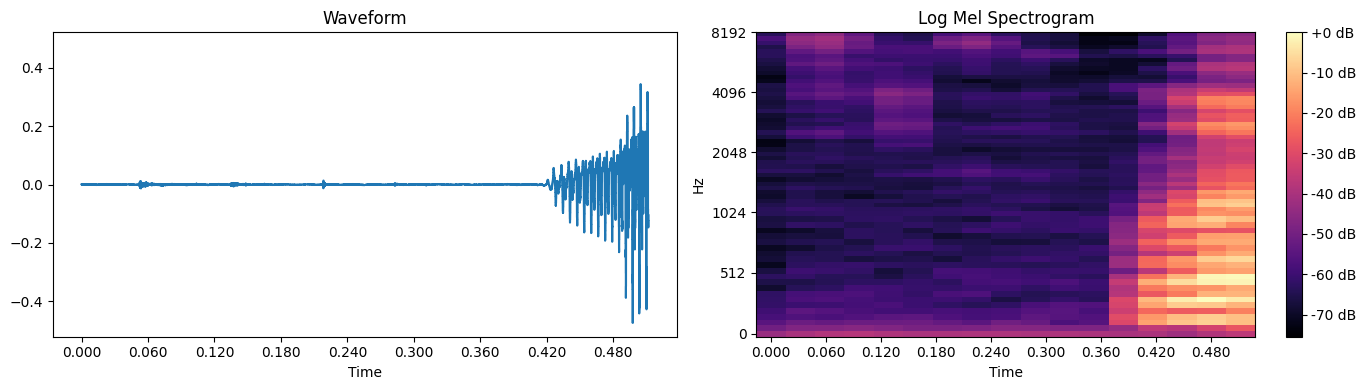

Class       : left
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


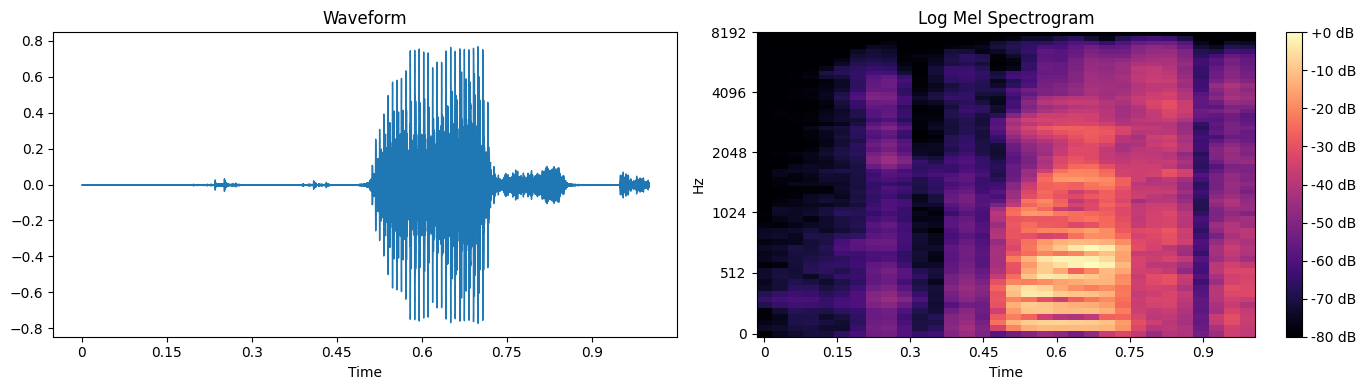

Class       : marvin
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


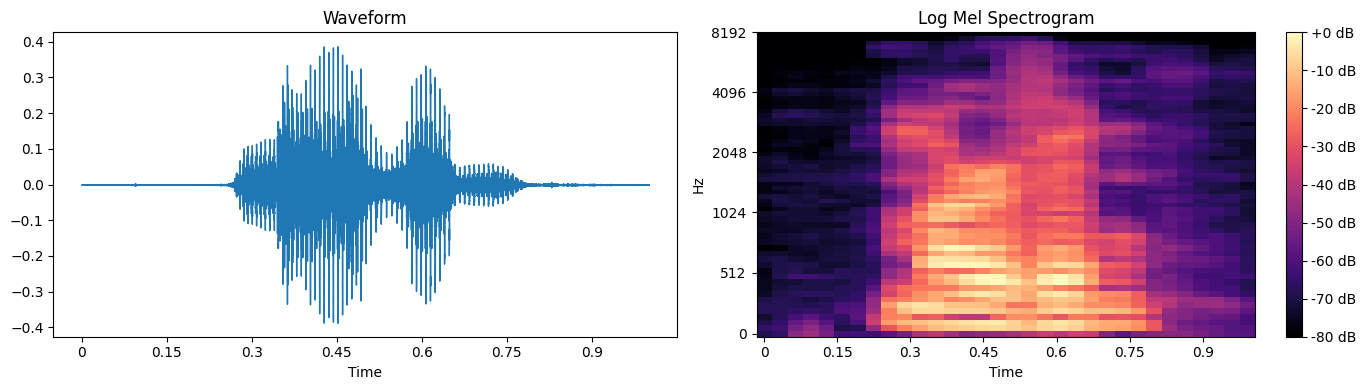

Class       : nine
File        : 00b01445_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


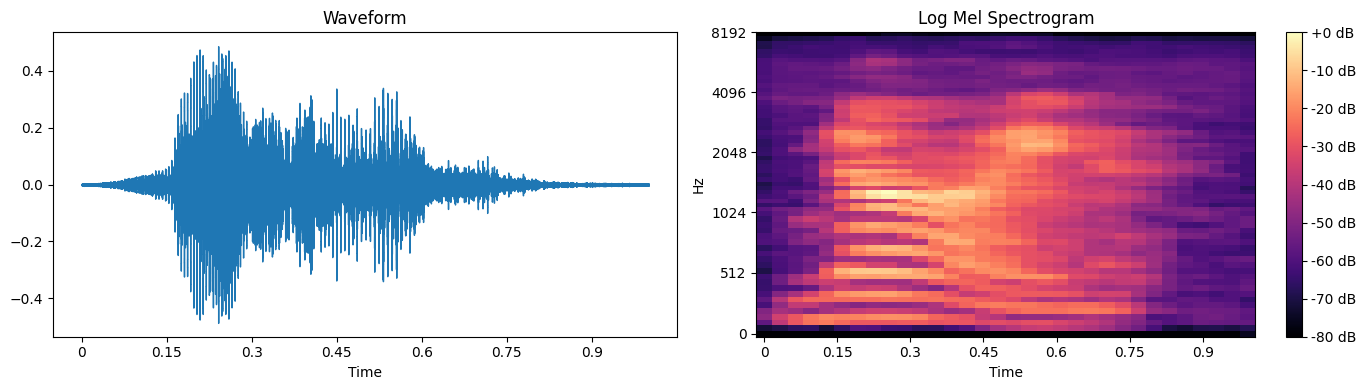

Class       : no
File        : 012c8314_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


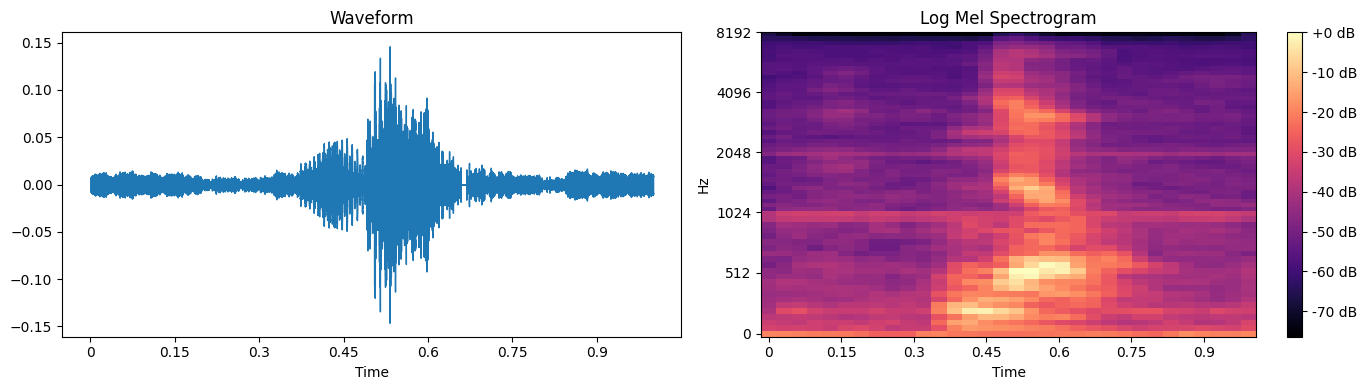

Class       : off
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


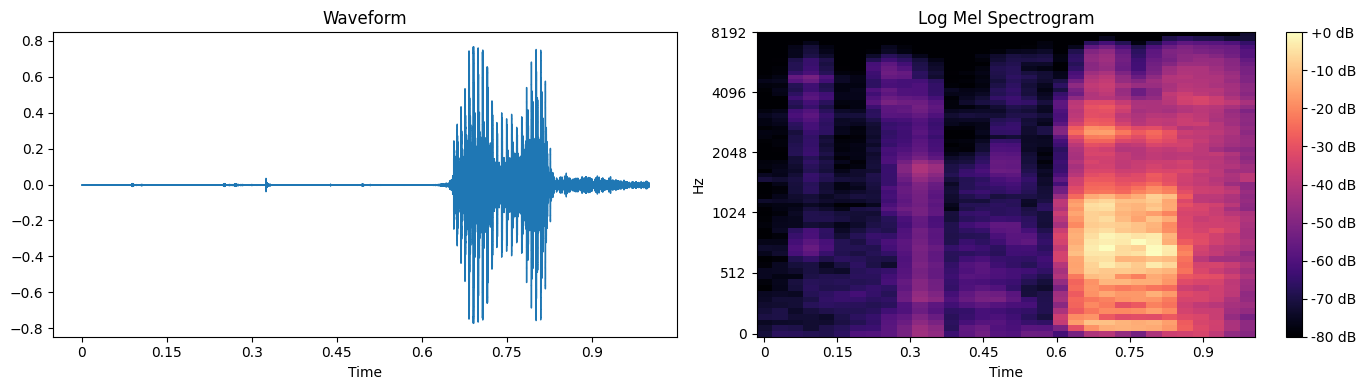

Class       : on
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.98 sec


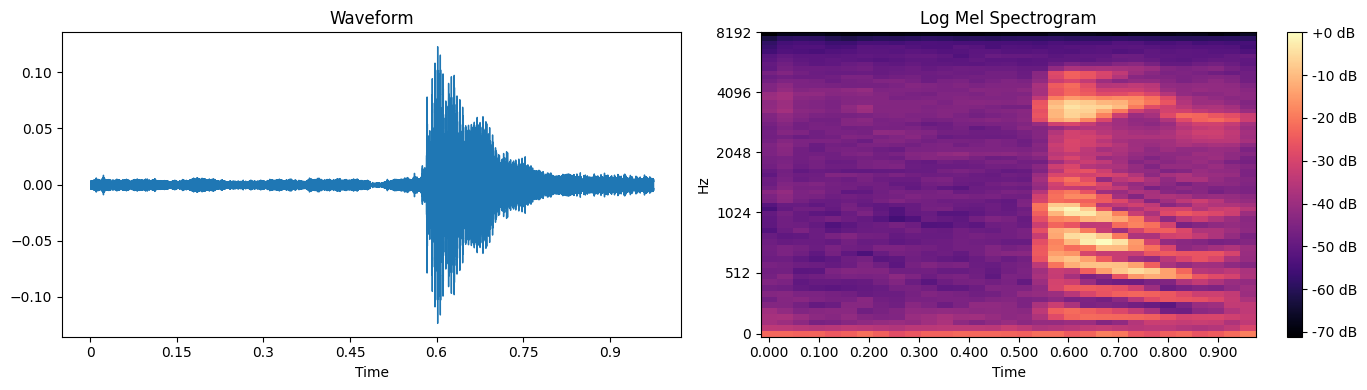

Class       : one
File        : 00176480_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


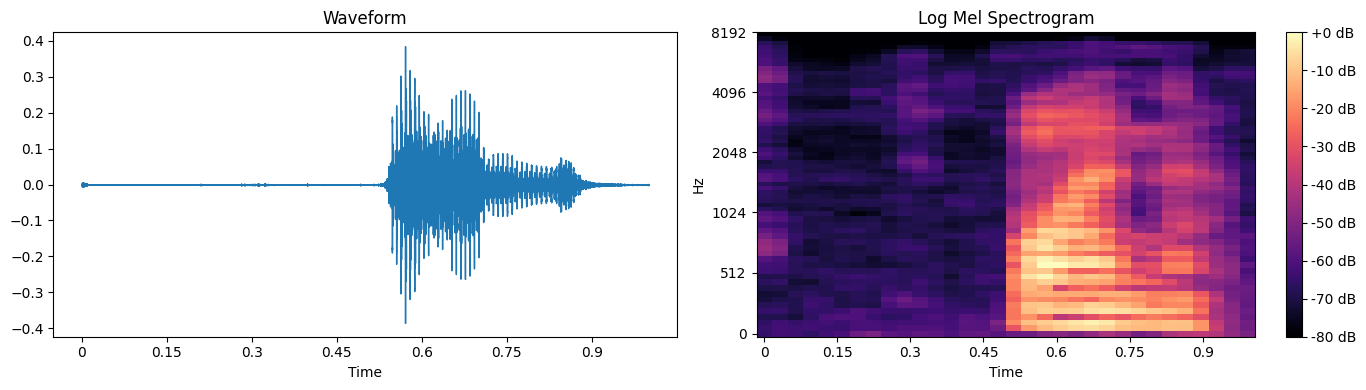

Class       : right
File        : 00b01445_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.90 sec


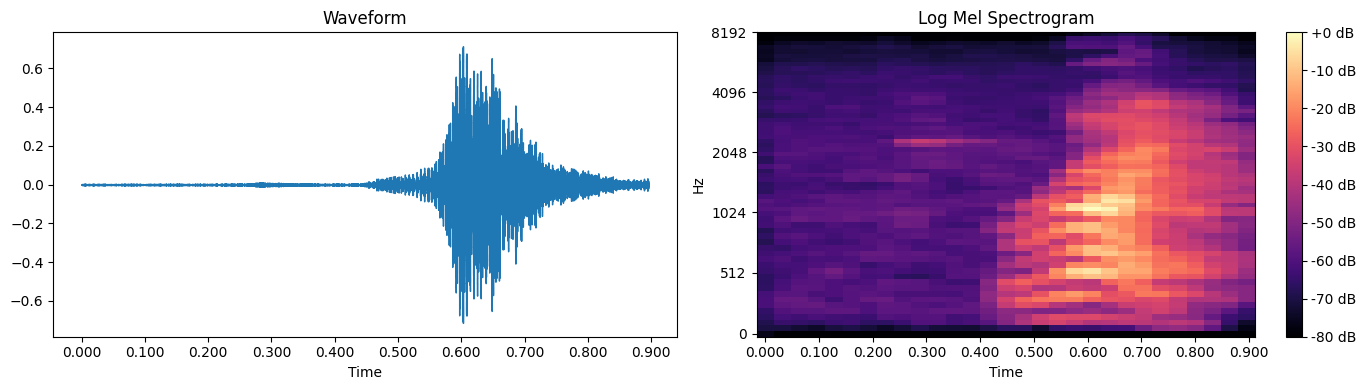

Class       : seven
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.74 sec


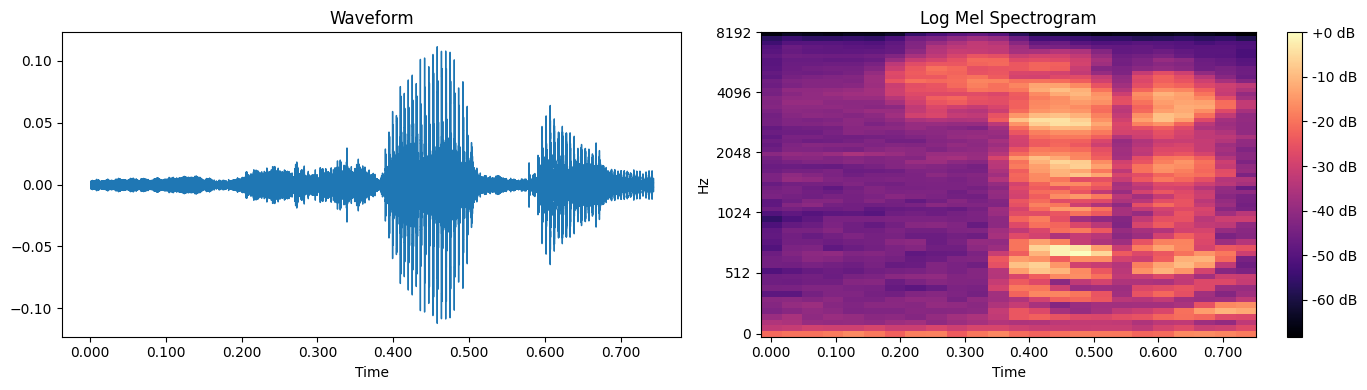

Class       : sheila
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


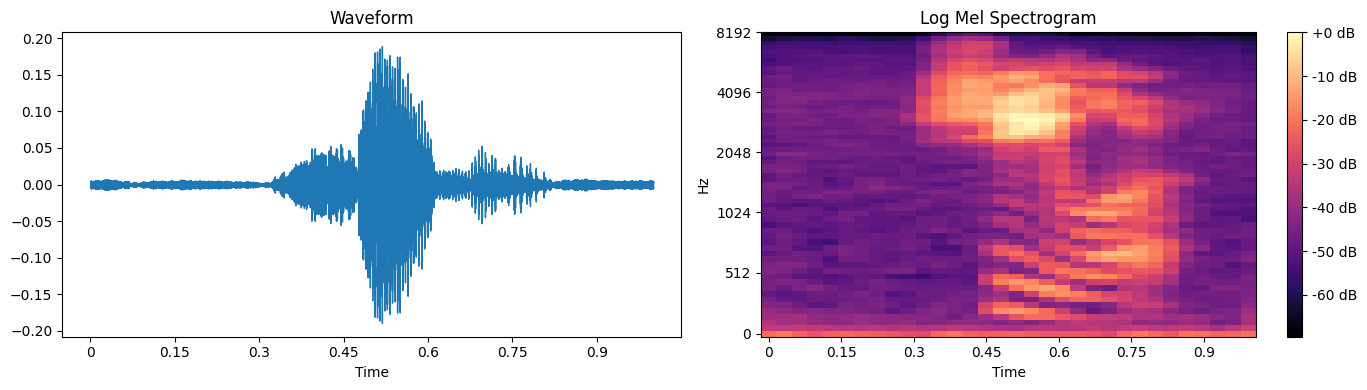

Class       : six
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.98 sec


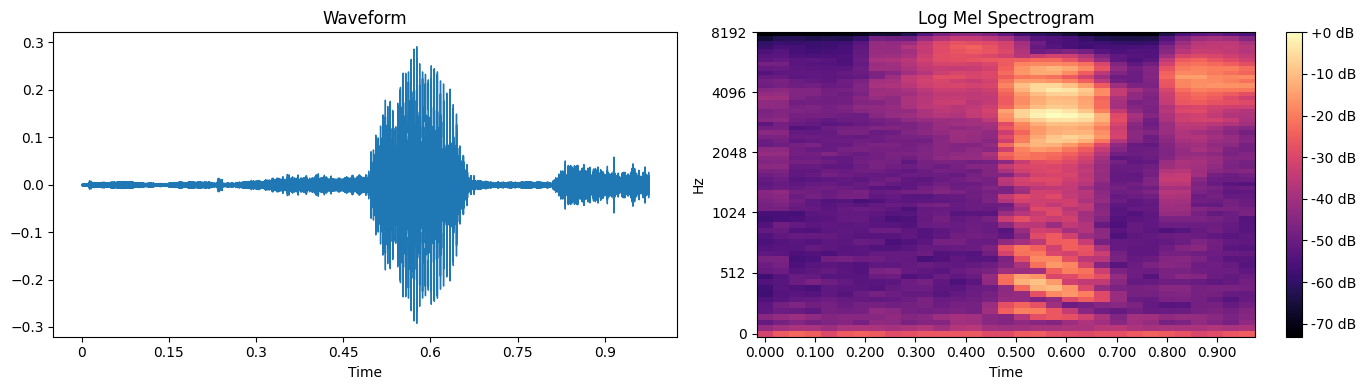

Class       : stop
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.84 sec


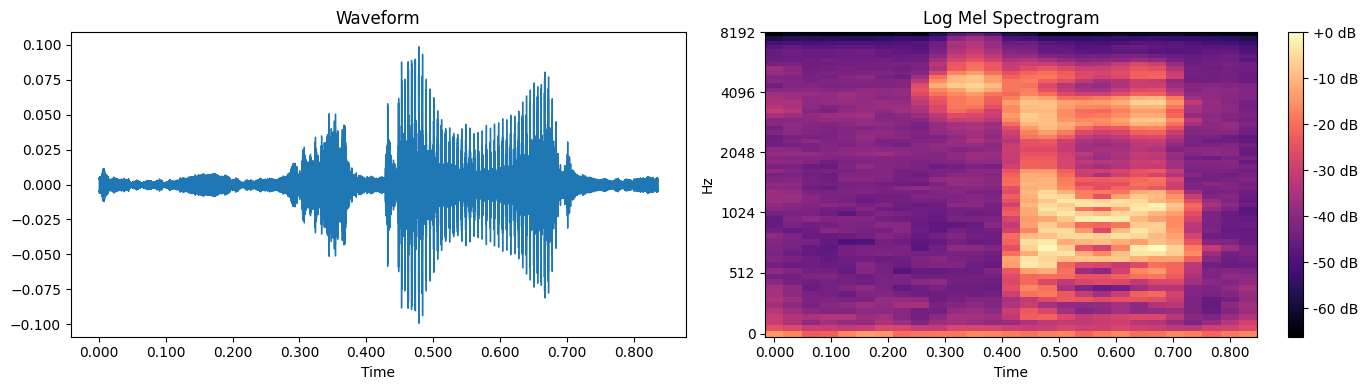

Class       : three
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.68 sec


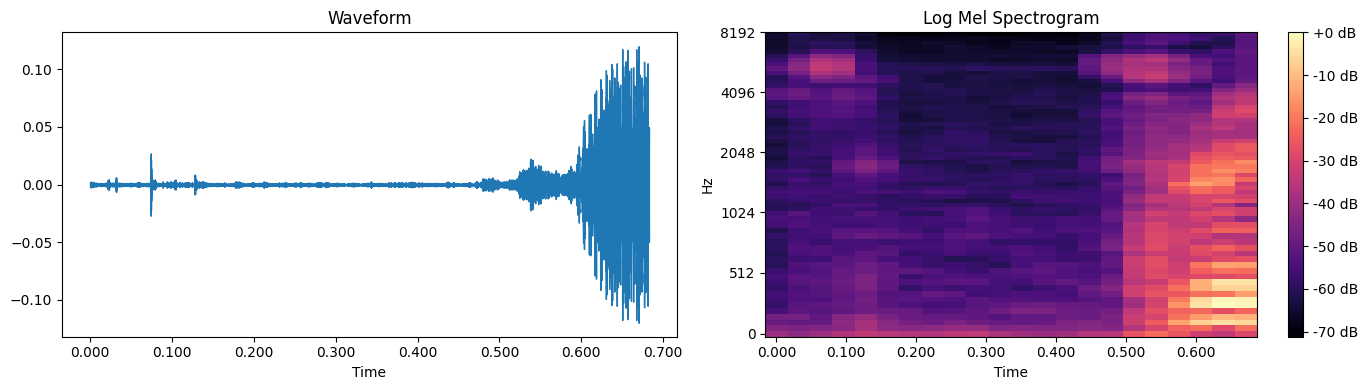

Class       : tree
File        : 00b01445_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


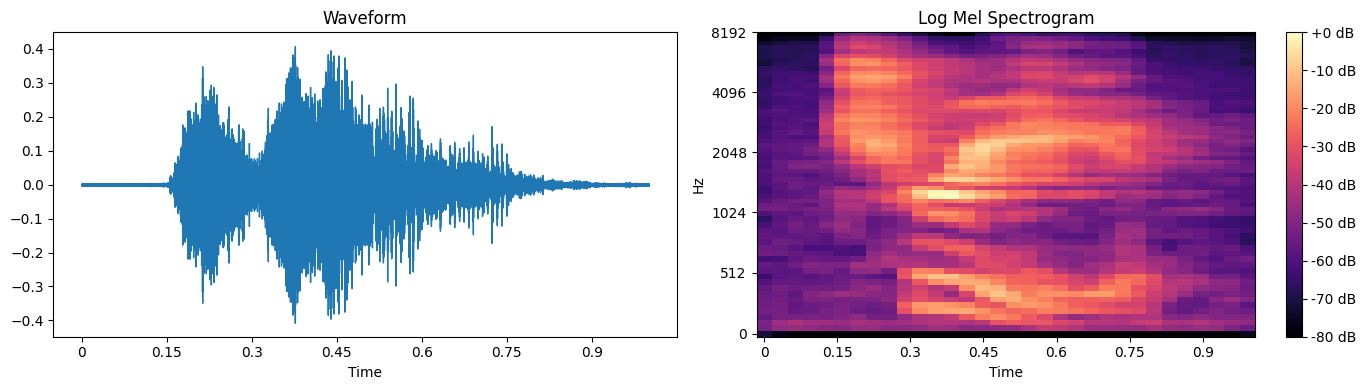

Class       : two
File        : 00b01445_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


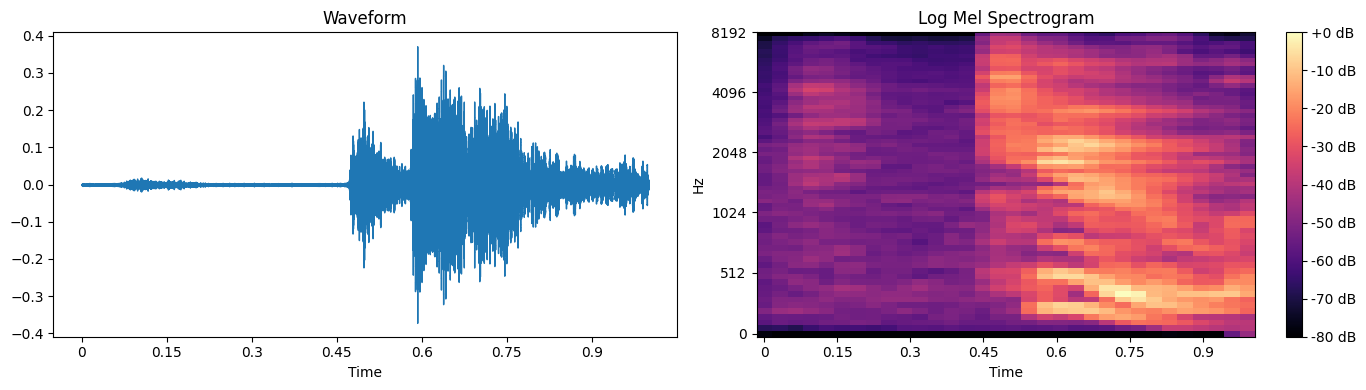

Class       : up
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.93 sec


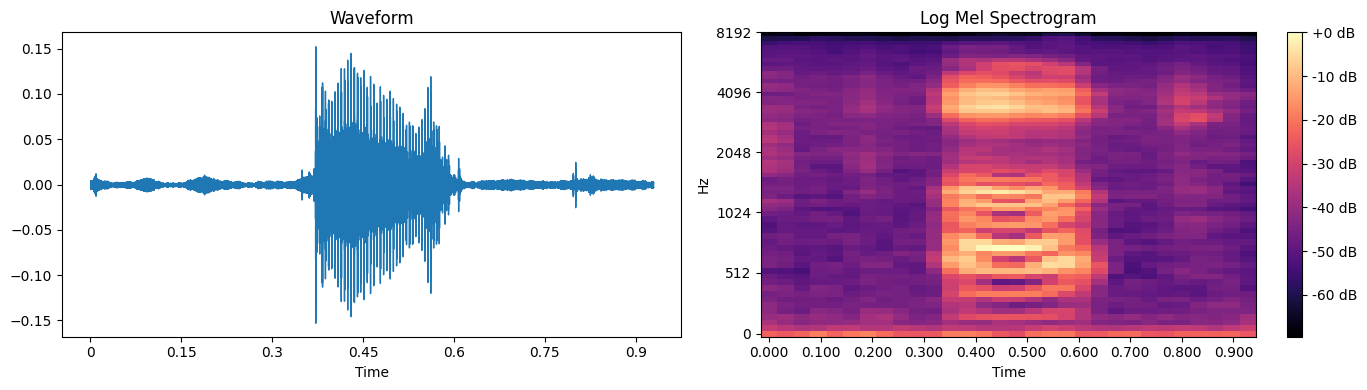

Class       : visual
File        : 00970ce1_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 0.85 sec


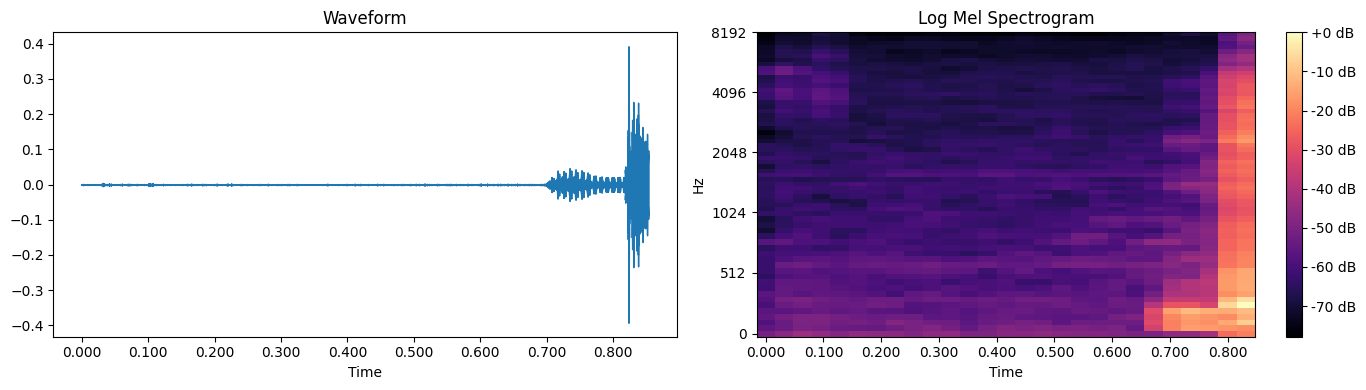

Class       : wow
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


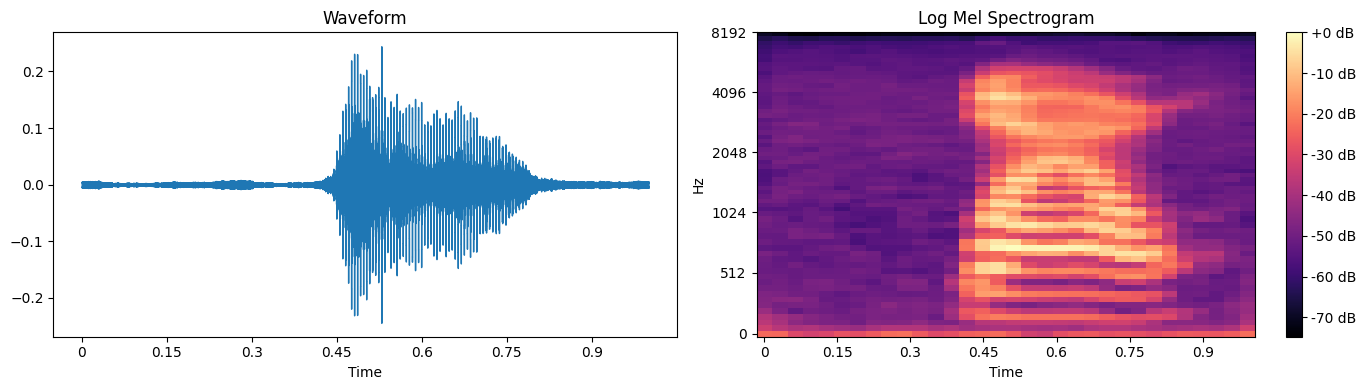

Class       : yes
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


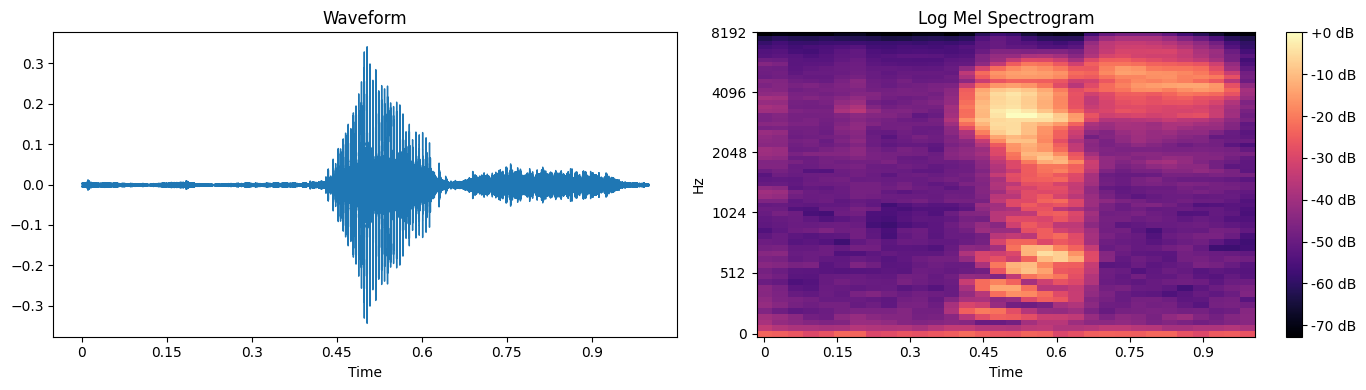

Class       : zero
File        : 004ae714_nohash_0.wav
Sample Rate : 16000 Hz
Duration    : 1.00 sec


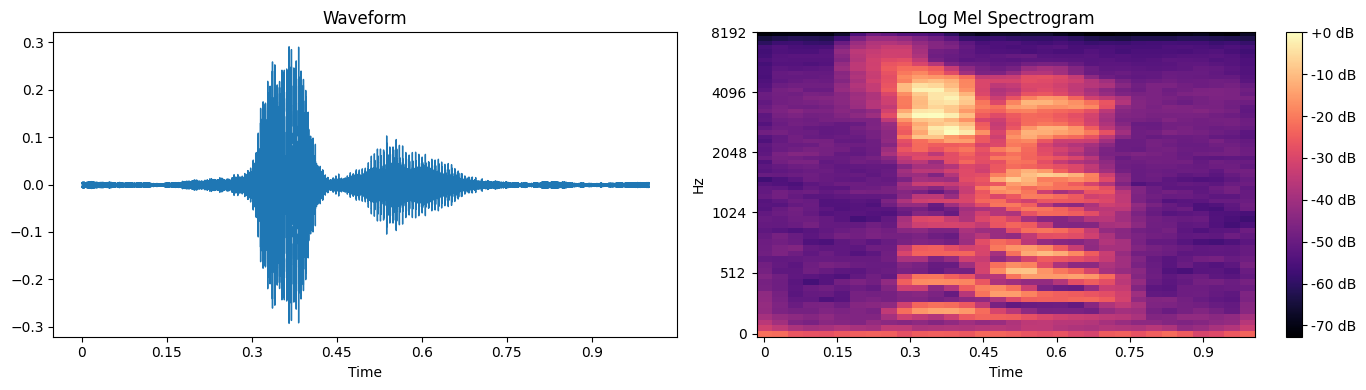

In [25]:
for cls in class_names:

    sample = glob.glob(
        os.path.join(DATASET_PATH, cls, "*.wav")
    )[0]

    visualize_audio(sample, cls)

In [26]:
class AudioPreprocessor:

    def __init__(
        self,
        sr=16000,
        n_mels=64,
        n_fft=1024,
        hop_length=512,
        target_duration=1.0
    ):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = int(sr * target_duration)

    def load_and_resample(self, path):

        y, original_sr = librosa.load(
            path,
            sr=None,
            mono=True
        )

        if original_sr != self.sr:

            y = librosa.resample(
                y,
                orig_sr=original_sr,
                target_sr=self.sr
            )

        return y

    def pad_or_truncate(self, y):

        if len(y) < self.target_samples:
    
            padding = self.target_samples - len(y)
    
            y = np.pad(
                y,
                (0, padding),
                mode="constant"
            )
    
        elif len(y) > self.target_samples:
    
            y = y[:self.target_samples]
    
        return y

    def extract_mel_spectrogram(self, y):

        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )
    
        log_mel = librosa.power_to_db(
            mel_spec,
            ref=np.max
        )
    
        # Add channel dimension
        log_mel = np.expand_dims(log_mel, axis=0)
    
        return log_mel

    def process(self, path):

        y = self.load_and_resample(path)
    
        y = self.pad_or_truncate(y)
    
        spec = self.extract_mel_spectrogram(y)
    
        return spec

In [27]:
preprocessor = AudioPreprocessor()

In [28]:
print("Sample Rate      :", preprocessor.sr)
print("Mel Bands        :", preprocessor.n_mels)
print("FFT Size         :", preprocessor.n_fft)
print("Hop Length       :", preprocessor.hop_length)
print("Target Samples   :", preprocessor.target_samples)

Sample Rate      : 16000
Mel Bands        : 64
FFT Size         : 1024
Hop Length       : 512
Target Samples   : 16000


In [29]:
sample_file = glob.glob(
    os.path.join(
        DATASET_PATH,
        class_names[0],
        "*.wav"
    )
)[0]

y = preprocessor.load_and_resample(sample_file)

print(type(y))

<class 'numpy.ndarray'>


In [30]:
print(y.shape)

(16000,)


In [31]:
print(y[:20])

[-0.06576538 -0.07092285 -0.07531738 -0.0793457  -0.08062744 -0.08175659
 -0.07696533 -0.07324219 -0.0690918  -0.06491089 -0.06637573 -0.06692505
 -0.07312012 -0.07855225 -0.08517456 -0.08905029 -0.09152222 -0.09182739
 -0.09173584 -0.09017944]


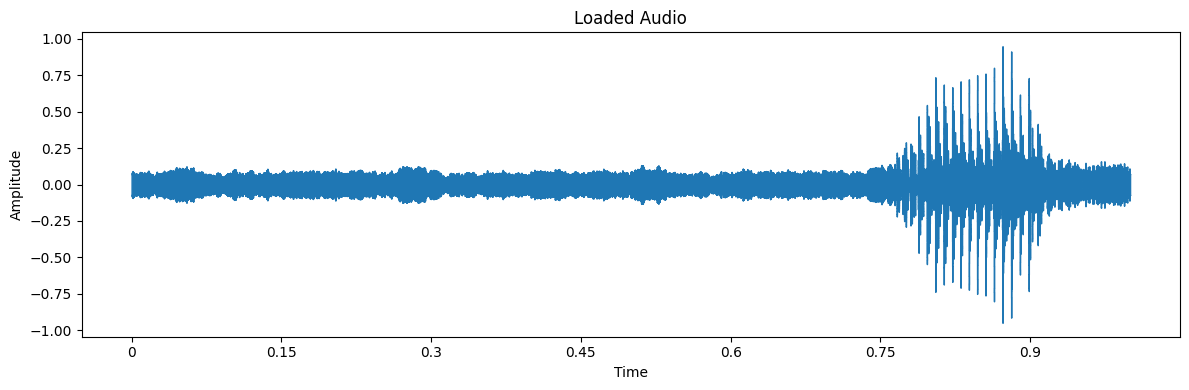

In [32]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    y,
    sr=preprocessor.sr
)

plt.title("Loaded Audio")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/raw_waveform.png"
)

plt.show()

In [33]:
y = preprocessor.load_and_resample(sample_file)

print("Original Length:", len(y))

y_fixed = preprocessor.pad_or_truncate(y)

print("Fixed Length:", len(y_fixed))

spec = preprocessor.extract_mel_spectrogram(y)

print(spec.shape)

Original Length: 16000
Fixed Length: 16000
(1, 64, 32)


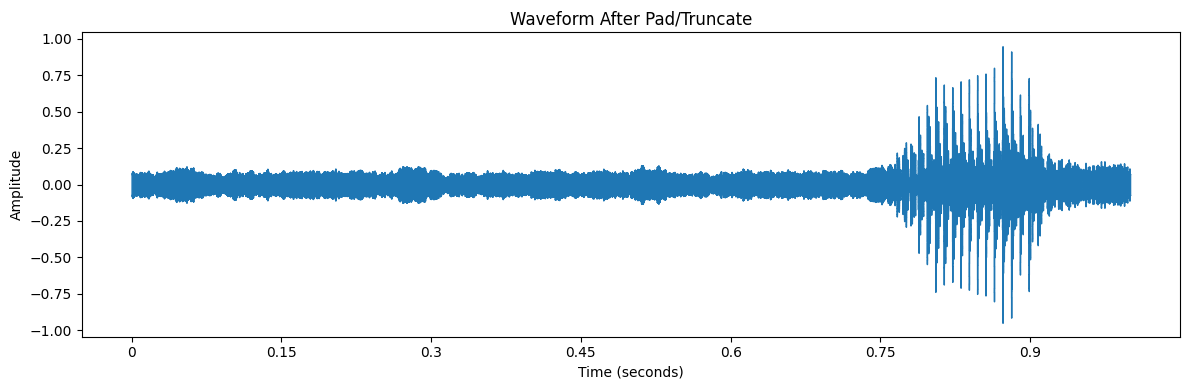

In [34]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    y_fixed,
    sr=preprocessor.sr
)

plt.title("Waveform After Pad/Truncate")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()

plt.savefig("../outputs/figures/padded_waveform.png")

plt.show()

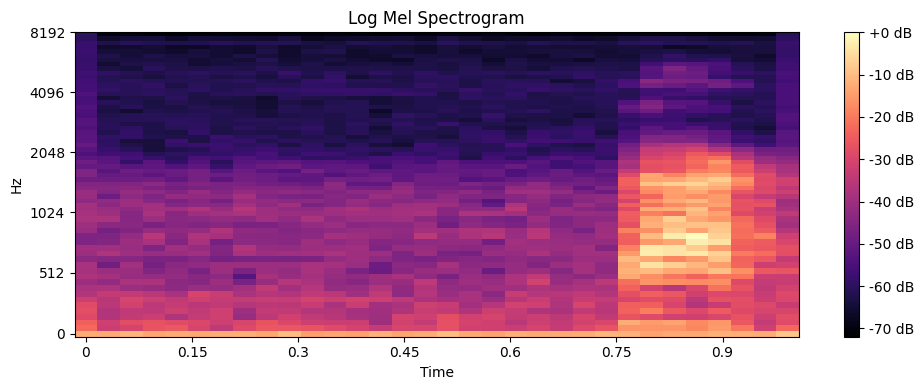

In [35]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    spec[0],
    sr=preprocessor.sr,
    hop_length=preprocessor.hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Log Mel Spectrogram")

plt.tight_layout()

plt.savefig("../outputs/figures/log_mel_spectrogram.png")

plt.show()

In [36]:
sample_file = glob.glob(
    os.path.join(
        DATASET_PATH,
        class_names[0],
        "*.wav"
    )
)[0]

spec = preprocessor.process(sample_file)

print(spec.shape)

(1, 64, 32)


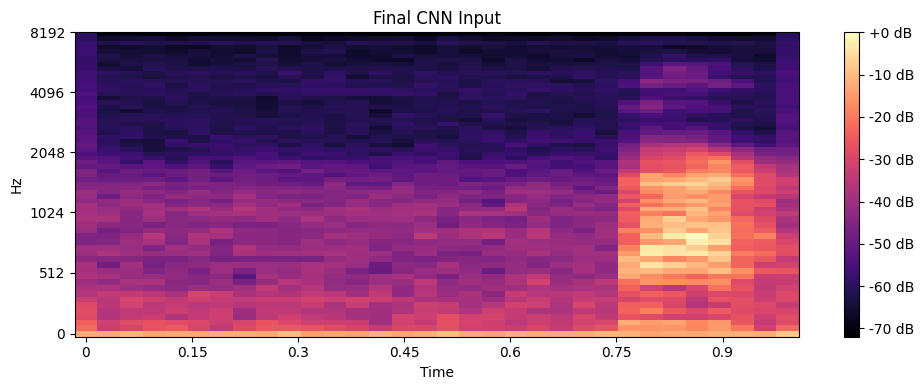

In [37]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    spec[0],
    sr=preprocessor.sr,
    hop_length=preprocessor.hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Final CNN Input")

plt.tight_layout()

plt.savefig("../outputs/figures/final_cnn_input.png")

plt.show()

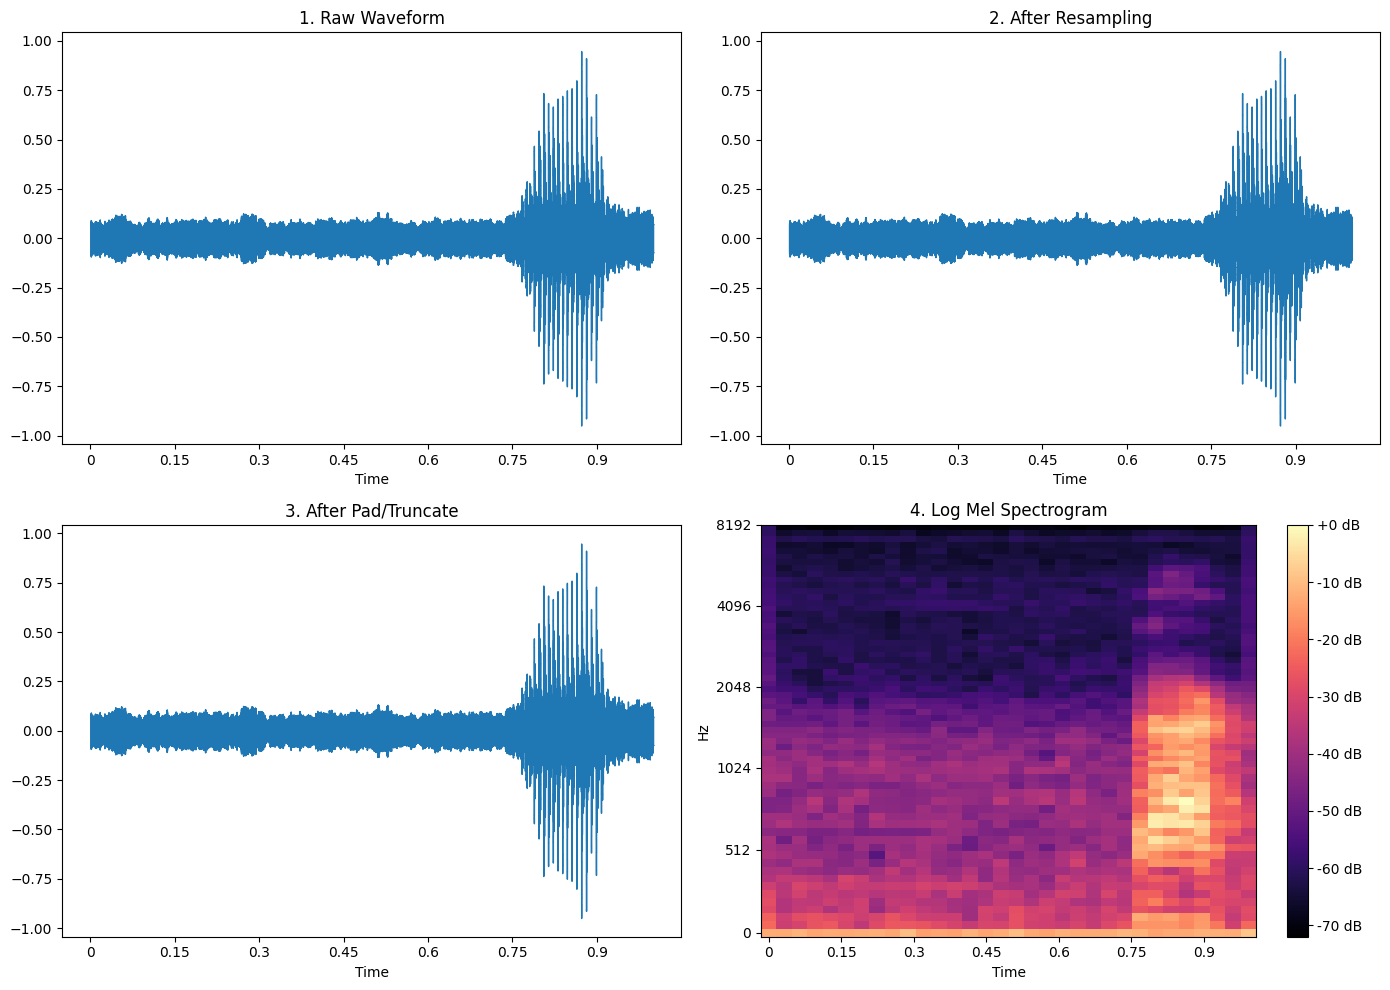

In [38]:
sample_file = glob.glob(
    os.path.join(DATASET_PATH, class_names[0], "*.wav")
)[0]

# Step 1: Raw Audio
raw_audio, raw_sr = librosa.load(sample_file, sr=None)

# Step 2: Resampled Audio
resampled_audio = preprocessor.load_and_resample(sample_file)

# Step 3: Pad/Truncate
fixed_audio = preprocessor.pad_or_truncate(resampled_audio)

# Step 4: Log Mel Spectrogram
mel_spec = preprocessor.extract_mel_spectrogram(fixed_audio)

plt.figure(figsize=(14,10))

# Plot 1
plt.subplot(2,2,1)
librosa.display.waveshow(raw_audio, sr=raw_sr)
plt.title("1. Raw Waveform")

# Plot 2
plt.subplot(2,2,2)
librosa.display.waveshow(resampled_audio, sr=preprocessor.sr)
plt.title("2. After Resampling")

# Plot 3
plt.subplot(2,2,3)
librosa.display.waveshow(fixed_audio, sr=preprocessor.sr)
plt.title("3. After Pad/Truncate")

# Plot 4
plt.subplot(2,2,4)
librosa.display.specshow(
    mel_spec[0],
    sr=preprocessor.sr,
    hop_length=preprocessor.hop_length,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("4. Log Mel Spectrogram")

plt.tight_layout()

plt.savefig("../outputs/figures/preprocessing_pipeline.png")

plt.show()

In [39]:
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import pickle

In [135]:
file_paths = []

labels = []

label_to_idx = {
    cls: idx
    for idx, cls in enumerate(class_names)
}

idx_to_label = {
    idx: cls
    for cls, idx in label_to_idx.items()
}

for cls in class_names:

    wavs = glob.glob(
        os.path.join(
            DATASET_PATH,
            cls,
            "*.wav"
        )
    )

    for file in wavs:

        file_paths.append(file)

        labels.append(
            label_to_idx[cls]
        )

print("Total files :", len(file_paths))

print("Total labels:", len(labels))

print(labels[:10])

Total files : 105829
Total labels: 105829
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [41]:
print(file_paths[:5])

print(labels[:5])

['../data/speech_commands_v0.02\\backward\\0165e0e8_nohash_0.wav', '../data/speech_commands_v0.02\\backward\\017c4098_nohash_0.wav', '../data/speech_commands_v0.02\\backward\\017c4098_nohash_1.wav', '../data/speech_commands_v0.02\\backward\\017c4098_nohash_2.wav', '../data/speech_commands_v0.02\\backward\\017c4098_nohash_3.wav']
['backward', 'backward', 'backward', 'backward', 'backward']


In [42]:
encoder = LabelEncoder()

encoded_labels = encoder.fit_transform(labels)

print(encoded_labels[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [43]:
label_mapping = {}

for i, cls in enumerate(encoder.classes_):

    label_mapping[cls] = i

label_mapping

{np.str_('backward'): 0,
 np.str_('bed'): 1,
 np.str_('bird'): 2,
 np.str_('cat'): 3,
 np.str_('dog'): 4,
 np.str_('down'): 5,
 np.str_('eight'): 6,
 np.str_('five'): 7,
 np.str_('follow'): 8,
 np.str_('forward'): 9,
 np.str_('four'): 10,
 np.str_('go'): 11,
 np.str_('happy'): 12,
 np.str_('house'): 13,
 np.str_('learn'): 14,
 np.str_('left'): 15,
 np.str_('marvin'): 16,
 np.str_('nine'): 17,
 np.str_('no'): 18,
 np.str_('off'): 19,
 np.str_('on'): 20,
 np.str_('one'): 21,
 np.str_('right'): 22,
 np.str_('seven'): 23,
 np.str_('sheila'): 24,
 np.str_('six'): 25,
 np.str_('stop'): 26,
 np.str_('three'): 27,
 np.str_('tree'): 28,
 np.str_('two'): 29,
 np.str_('up'): 30,
 np.str_('visual'): 31,
 np.str_('wow'): 32,
 np.str_('yes'): 33,
 np.str_('zero'): 34}

In [44]:
with open(
    "../models/label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(encoder, f)

In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(

    file_paths,

    encoded_labels,

    test_size=0.30,

    random_state=42,

    stratify=encoded_labels
)

In [46]:
X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

In [47]:
print("Training   :", len(X_train))

print("Validation :", len(X_val))

print("Testing    :", len(X_test))

Training   : 74080
Validation : 15874
Testing    : 15875


In [48]:
print(pd.Series(y_train).value_counts().sort_index())

0     1165
1     1410
2     1445
3     1422
4     1490
5     2742
6     2651
7     2836
8     1105
9     1090
10    2610
11    2716
12    1438
13    1479
14    1102
15    2661
16    1470
17    2754
18    2759
19    2621
20    2691
21    2723
22    2645
23    2799
24    1415
25    2702
26    2710
27    2609
28    1231
29    2716
30    2606
31    1114
32    1486
33    2831
34    2836
Name: count, dtype: int64


In [49]:
class AudioDataset(Dataset):

    def __init__(self, file_list, labels, preprocessor, augment=None):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        file_path = self.file_list[idx]
        label = self.labels[idx]

        spec = self.preprocessor.process(file_path)

        spec = torch.tensor(
            spec,
            dtype=torch.float32
        )

        if self.augment is not None:
            spec = self.augment(spec)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return spec, label

In [50]:
train_dataset = AudioDataset(

    X_train,

    y_train,

    preprocessor
)

val_dataset = AudioDataset(

    X_val,

    y_val,

    preprocessor
)

test_dataset = AudioDataset(

    X_test,

    y_test,

    preprocessor
)

In [51]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

74080
15874
15875


In [52]:
spec, label = train_dataset[0]

print(spec.shape)

print(label)

torch.Size([1, 64, 32])
tensor(8)


In [53]:
BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)

In [54]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 1, 64, 32])
torch.Size([32])


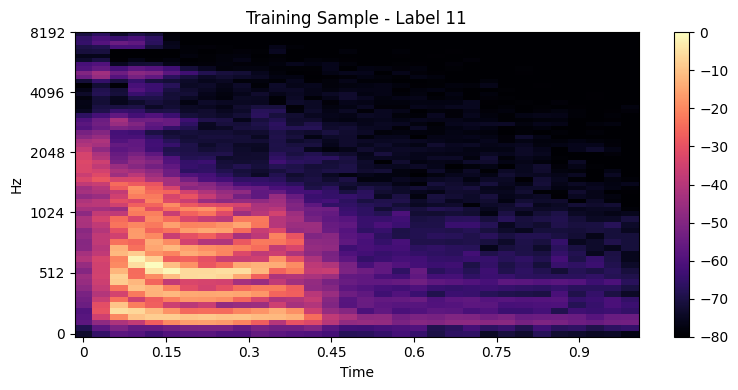

In [55]:
plt.figure(figsize=(8,4))

librosa.display.specshow(

    images[0][0].numpy(),

    sr=preprocessor.sr,

    hop_length=preprocessor.hop_length,

    x_axis="time",

    y_axis="mel"
)

plt.colorbar()

plt.title(

    f"Training Sample - Label {labels[0].item()}"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/train_sample.png"
)

plt.show()

In [56]:
import torch.nn as nn

class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.30)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

In [57]:
NUM_CLASSES = len(class_names)

model = AudioCNN(NUM_CLASSES)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=64, out_features=35, bias=True)
)


In [58]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print(device)

model = model.to(device)

cuda


In [59]:
total = sum(

    p.numel()

    for p in model.parameters()
)

trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print("Total Parameters :", total)

print("Trainable :", trainable)

Total Parameters : 25795
Trainable : 25795


In [60]:
images, labels = next(iter(train_loader))

images = images.to(device)

output = model(images)

print(output.shape)

torch.Size([32, 35])


In [61]:
predictions = torch.argmax(output, dim=1)

print(predictions.shape)

print(predictions[:10])

torch.Size([32])
tensor([4, 4, 8, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')


In [62]:
for i in range(5):

    predicted = encoder.inverse_transform(
        [predictions[i].cpu().item()]
    )[0]

    actual = encoder.inverse_transform(
        [labels[i].item()]
    )[0]

    print(f"Predicted : {predicted}")

    print(f"Actual    : {actual}")

    print("-"*40)

Predicted : dog
Actual    : bed
----------------------------------------
Predicted : dog
Actual    : forward
----------------------------------------
Predicted : follow
Actual    : dog
----------------------------------------
Predicted : dog
Actual    : up
----------------------------------------
Predicted : dog
Actual    : eight
----------------------------------------


In [63]:
images, labels = next(iter(train_loader))

output = model(images.to(device))

print(output.shape)

torch.Size([32, 35])


In [64]:
import torch.optim as optim

EPOCHS = 20
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [75]:
import torch.optim as optim

EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [76]:
train_losses = []

train_accs = []

val_accs = []

best_val_acc = 0

In [77]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)

    acc = 100 * correct / total

    return loss, acc

In [78]:
def validate(model, loader):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total

    return acc

In [79]:
print(next(model.parameters()).device)

cuda:0


In [80]:
images, labels = next(iter(train_loader))

print(images.device)

images = images.to(device)

print(images.device)

cpu
cuda:0


In [82]:
#Only for training

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_acc = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Loss : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy : {train_acc:.2f}%"
    )

    print(
        f"Validation Accuracy : {val_acc:.2f}%"
    )

    print("-"*50)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "../models/best_model_without_aug.pth"
        )

Epoch 1/10
Loss : 1.0157
Train Accuracy : 71.15%
Validation Accuracy : 72.68%
--------------------------------------------------
Epoch 2/10
Loss : 0.8847
Train Accuracy : 74.54%
Validation Accuracy : 74.61%
--------------------------------------------------
Epoch 3/10
Loss : 0.8040
Train Accuracy : 76.79%
Validation Accuracy : 80.04%
--------------------------------------------------
Epoch 4/10
Loss : 0.7433
Train Accuracy : 78.18%
Validation Accuracy : 77.83%
--------------------------------------------------
Epoch 5/10
Loss : 0.7043
Train Accuracy : 79.33%
Validation Accuracy : 82.05%
--------------------------------------------------
Epoch 6/10
Loss : 0.6701
Train Accuracy : 80.27%
Validation Accuracy : 81.80%
--------------------------------------------------
Epoch 7/10
Loss : 0.6383
Train Accuracy : 81.24%
Validation Accuracy : 83.41%
--------------------------------------------------
Epoch 8/10
Loss : 0.6180
Train Accuracy : 81.80%
Validation Accuracy : 84.97%
-------------------

In [90]:
# ============================================
# PART A MODEL ALREADY TRAINED
# ============================================

print("="*60)
print("Training already completed.")
print("Loading saved model...")
print("="*60)

model = AudioCNN(num_classes=NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "../models/best_model_without_aug.pth",
        map_location=device
    )
)

model.eval()

print("Model loaded successfully.")

Training already completed.
Loading saved model...
Model loaded successfully.


In [91]:
print(
    f"Best Validation Accuracy : {best_val_acc:.2f}%"
)

Best Validation Accuracy : 84.97%


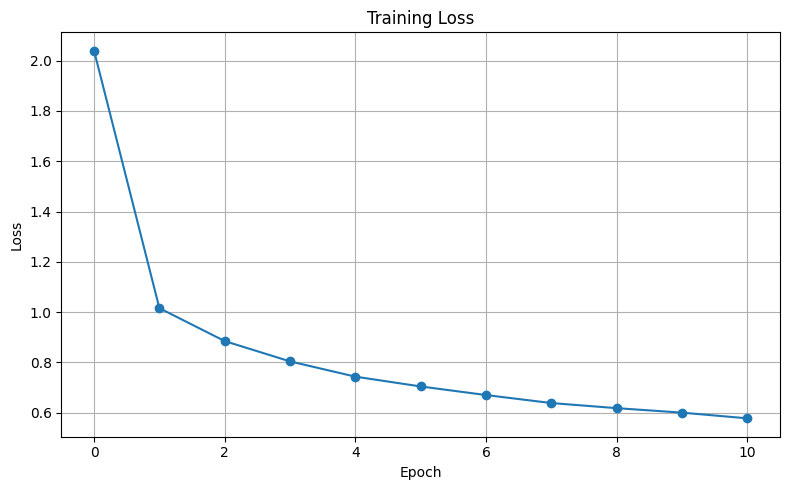

In [84]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/training_curves/training_loss.png"
)

plt.show()

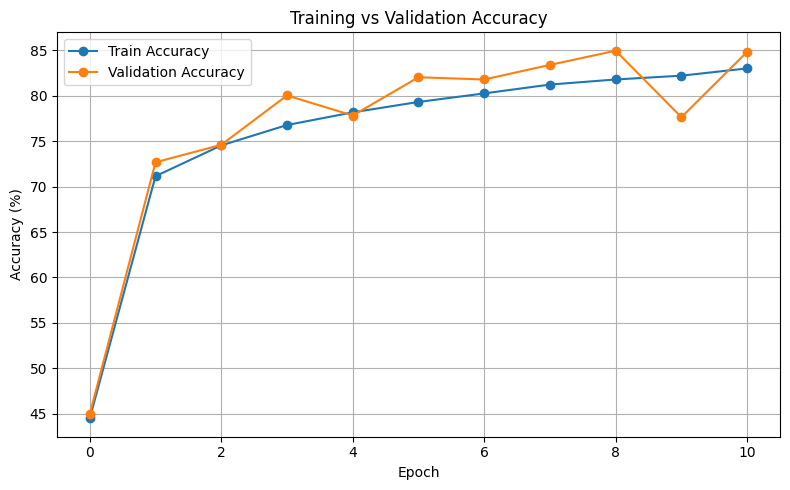

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy",
    marker='o'
)

plt.plot(
    val_accs,
    label="Validation Accuracy",
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/training_curves/train_vs_validation.png"
)

plt.show()

In [92]:
import pandas as pd

history = pd.read_csv(
    "../outputs/training_curves/training_history.csv"
)

history.head()

,Epoch,Train Loss,Train Accuracy,Validation Accuracy
0,1,2.039714,44.489741,44.954013
1,2,1.015660,71.152808,72.684894
2,3,0.884712,74.539687,74.606274
3,4,0.804008,76.785907,80.042837
4,5,0.743308,78.180346,77.831674


In [87]:
print("EPOCHS:", EPOCHS)
print("train_losses:", len(train_losses))
print("train_accs:", len(train_accs))
print("val_accs:", len(val_accs))

EPOCHS: 10
train_losses: 11
train_accs: 11
val_accs: 11


In [88]:
print(len(train_losses))

11


In [93]:
import os

print(
    os.path.exists(
        "../models/best_model_without_aug.pth"
    )
)

True


In [94]:
model = AudioCNN(
    num_classes=NUM_CLASSES
).to(device)

model.load_state_dict(
    torch.load(
        "../models/best_model_without_aug.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [97]:
model.load_state_dict(
    torch.load(
        "../models/best_model_without_aug.pth",
        map_location=device
    )
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Total Test Samples :", len(all_labels))
print("Total Predictions :", len(all_predictions))

Total Test Samples : 15875
Total Predictions : 15875


In [98]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall : {macro_recall:.4f}")
print(f"Macro F1 Score : {macro_f1:.4f}")

Test Accuracy : 84.37%
Macro Precision : 0.8416
Macro Recall : 0.8295
Macro F1 Score : 0.8322


In [99]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../outputs/predictions/classification_report.csv"
)

report_df

,precision,recall,f1-score,support
backward,0.822878,0.895582,0.857692,249.000000
bed,0.743284,0.824503,0.781790,302.000000
bird,0.783019,0.805825,0.794258,309.000000
cat,0.740000,0.851974,0.792049,304.000000
dog,0.866906,0.755486,0.807370,319.000000
down,0.930958,0.710884,0.806172,588.000000
eight,0.791793,0.917254,0.849918,568.000000
five,0.898936,0.833882,0.865188,608.000000
follow,0.700461,0.641350,0.669604,237.000000
forward,0.703863,0.703863,0.703863,233.000000


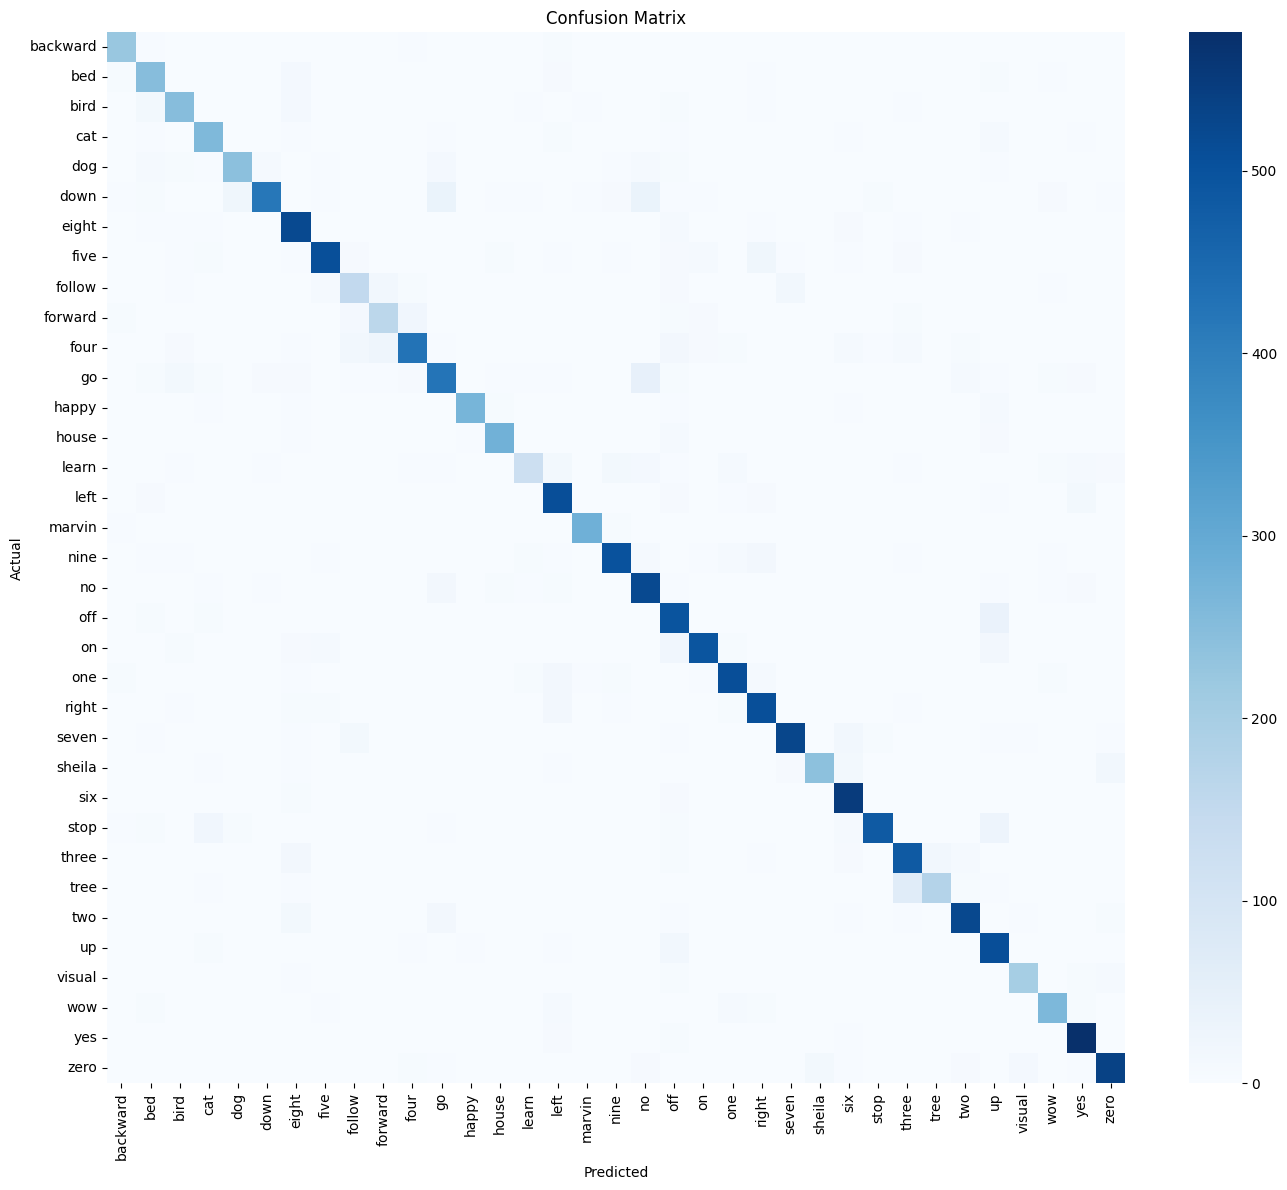

In [100]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix/confusion_matrix_without_aug.png",
    dpi=300
)

plt.show()

In [101]:
prediction_results = []

model.eval()

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)

        outputs = model(spectrograms)

        predictions = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):

            prediction_results.append({

                "spectrogram": spectrograms[i].cpu(),

                "actual": labels[i].item(),

                "predicted": predictions[i].cpu().item()

            })

print("Collected", len(prediction_results), "predictions")

Collected 15875 predictions


In [102]:
correct_predictions = []

incorrect_predictions = []

for sample in prediction_results:

    if sample["actual"] == sample["predicted"]:

        correct_predictions.append(sample)

    else:

        incorrect_predictions.append(sample)

print("Correct :", len(correct_predictions))

print("Incorrect :", len(incorrect_predictions))

Correct : 13394
Incorrect : 2481


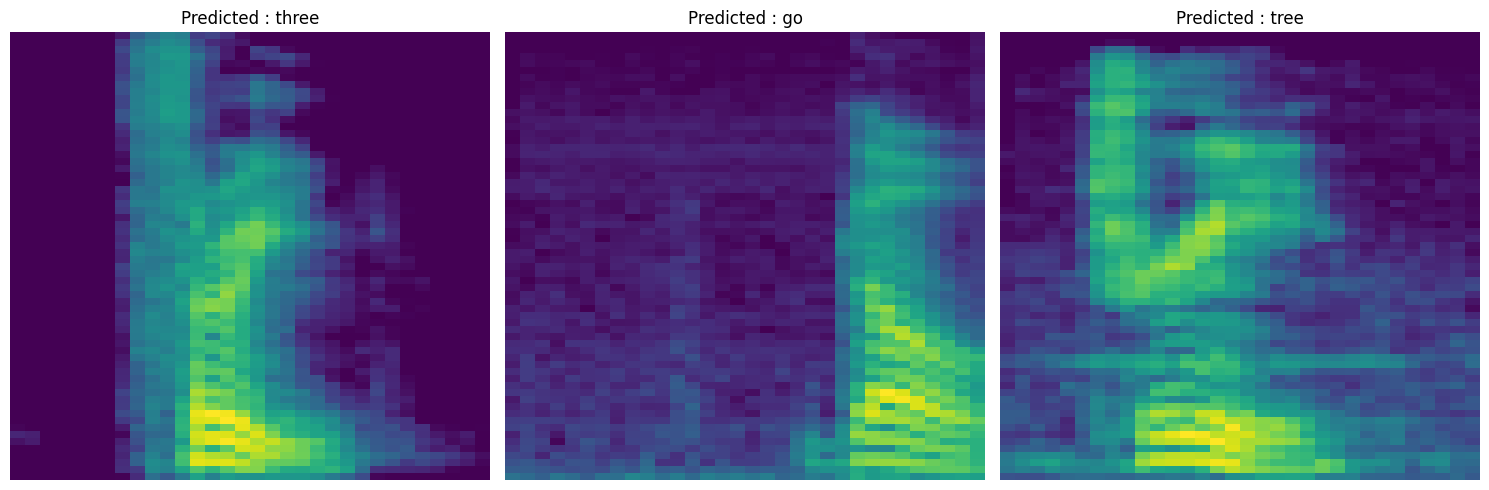

In [103]:
plt.figure(figsize=(15,5))

for i in range(3):

    sample = correct_predictions[i]

    plt.subplot(1,3,i+1)

    plt.imshow(
        sample["spectrogram"].squeeze(0),
        aspect="auto",
        origin="lower"
    )

    plt.title(
        f"Predicted : {class_names[sample['predicted']]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/predictions/correct_predictions.png",
    dpi=300
)

plt.show()

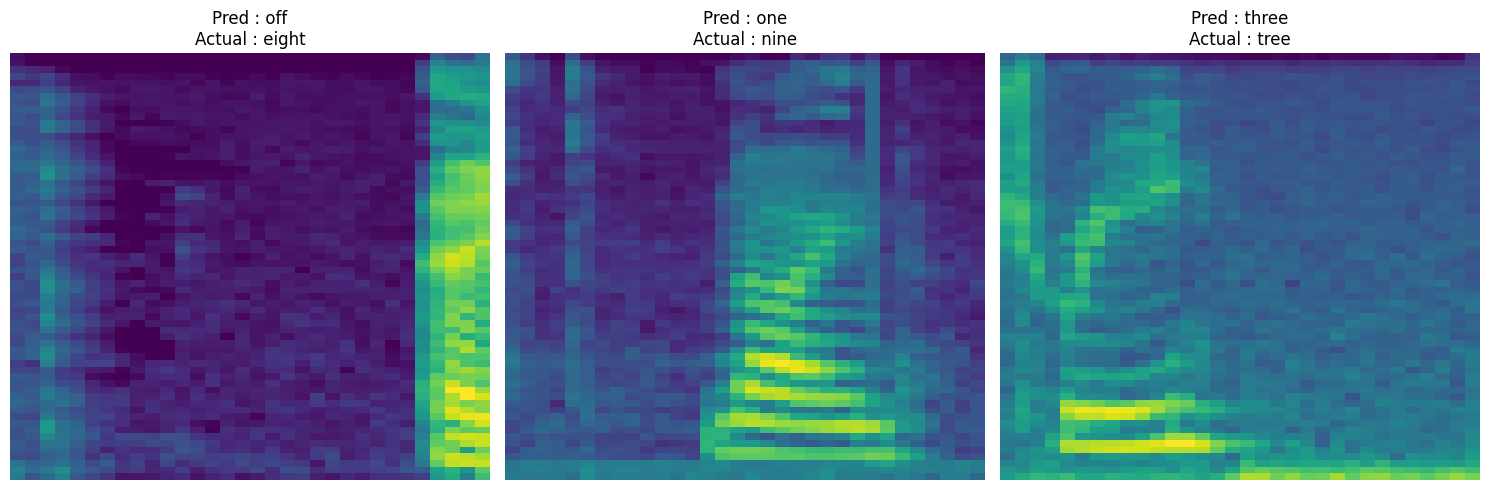

In [104]:
plt.figure(figsize=(15,5))

for i in range(3):

    sample = incorrect_predictions[i]

    plt.subplot(1,3,i+1)

    plt.imshow(
        sample["spectrogram"].squeeze(0),
        aspect="auto",
        origin="lower"
    )

    plt.title(
        f"Pred : {class_names[sample['predicted']]}\n"
        f"Actual : {class_names[sample['actual']]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/predictions/incorrect_predictions.png",
    dpi=300
)

plt.show()

In [105]:
evaluation_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],

    "Value":[
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ]

})

evaluation_summary.to_csv(

    "../outputs/predictions/evaluation_summary.csv",

    index=False

)

evaluation_summary

,Metric,Value
0,Accuracy,0.843717
1,Macro Precision,0.841569
2,Macro Recall,0.829542
3,Macro F1 Score,0.832173


In [106]:
import random
import torch


class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=35,
        num_freq_masks=2,
        num_time_masks=2
    ):

        self.F = freq_mask_param
        self.T = time_mask_param

        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks


    def freq_mask(self, spec):

        _, n_mels, _ = spec.shape

        f = random.randint(0, min(self.F, n_mels // 4))

        if f == 0:
            return spec

        f0 = random.randint(
            0,
            max(0, n_mels - f)
        )

        spec[:, f0:f0+f, :] = spec.min()

        return spec


    def time_mask(self, spec):

        _, _, n_frames = spec.shape

        t = random.randint(0, min(self.T, n_frames // 4))

        if t == 0:
            return spec

        t0 = random.randint(
            0,
            max(0, n_frames - t)
        )

        spec[:, :, t0:t0+t] = spec.min()

        return spec


    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):

            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):

            spec = self.time_mask(spec)

        return spec

In [107]:
augment = SpecAugment(
    freq_mask_param=6,
    time_mask_param=6,
    num_freq_masks=2,
    num_time_masks=2
) 

print("SpecAugment Ready")

SpecAugment Ready


In [108]:
sample_spec, sample_label = train_dataset[0]

print(sample_spec.shape)

torch.Size([1, 64, 32])


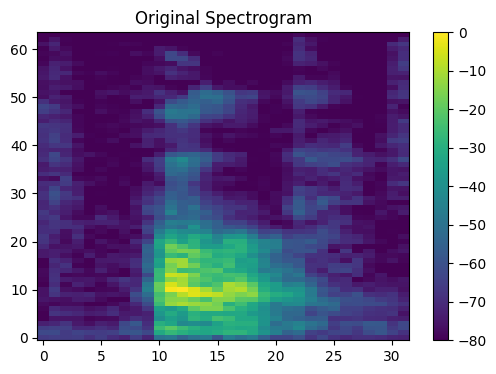

In [109]:
plt.figure(figsize=(6,4))

plt.imshow(
    sample_spec.squeeze(0),
    origin="lower",
    aspect="auto"
)

plt.title("Original Spectrogram")

plt.colorbar()

plt.show()

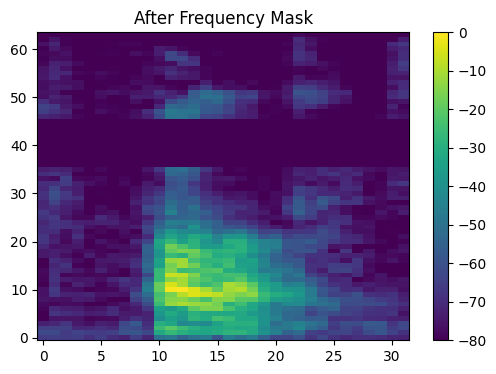

In [110]:
freq_aug = SpecAugment(
    freq_mask_param=15,
    time_mask_param=0,
    num_freq_masks=1,
    num_time_masks=0
)

freq_spec = freq_aug(sample_spec)

plt.figure(figsize=(6,4))

plt.imshow(
    freq_spec.squeeze(0),
    origin="lower",
    aspect="auto"
)

plt.title("After Frequency Mask")

plt.colorbar()

plt.show()

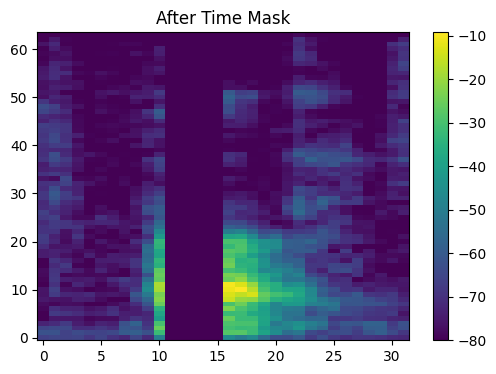

In [111]:
time_aug = SpecAugment(
    freq_mask_param=0,
    time_mask_param=35,
    num_freq_masks=0,
    num_time_masks=1
)

time_spec = time_aug(sample_spec)

plt.figure(figsize=(6,4))

plt.imshow(
    time_spec.squeeze(0),
    origin="lower",
    aspect="auto"
)

plt.title("After Time Mask")

plt.colorbar()

plt.show()

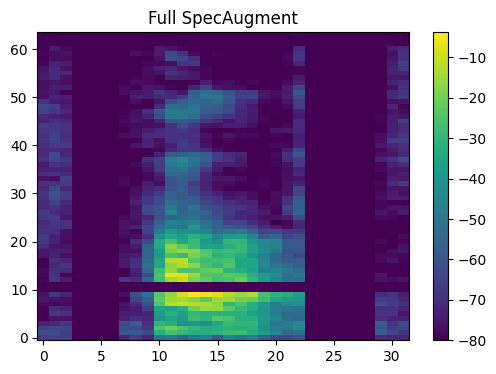

In [112]:
augmented_spec = augment(sample_spec)

plt.figure(figsize=(6,4))

plt.imshow(
    augmented_spec.squeeze(0),
    origin="lower",
    aspect="auto"
)

plt.title("Full SpecAugment")

plt.colorbar()

plt.show()

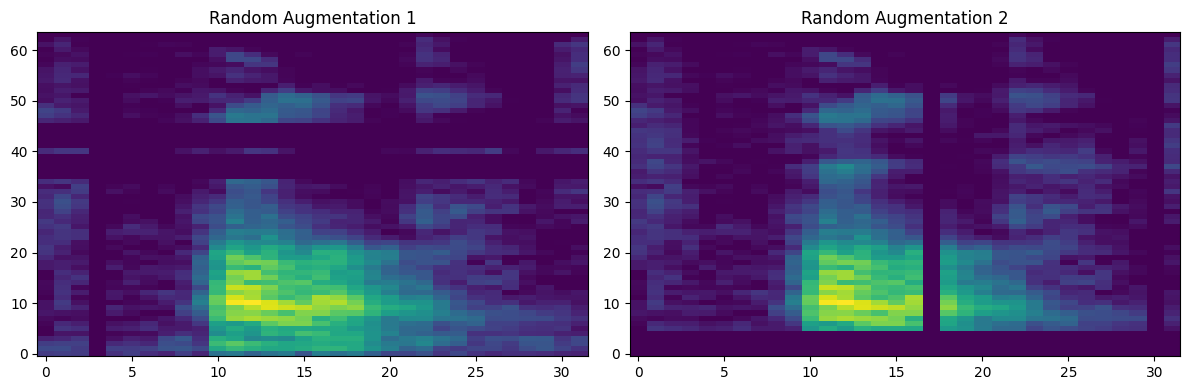

In [113]:
plt.figure(figsize=(12,4))

for i in range(2):

    aug = augment(sample_spec)

    plt.subplot(1,2,i+1)

    plt.imshow(
        aug.squeeze(0),
        origin="lower",
        aspect="auto"
    )

    plt.title(
        f"Random Augmentation {i+1}"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/specaugment_examples.png",
    dpi=300
)

plt.show()

In [114]:
sample_spec, sample_label = train_dataset[0]

print(sample_spec.shape)
print(sample_spec.min())
print(sample_spec.max())
print(sample_spec.mean())

torch.Size([1, 64, 32])
tensor(-80.)
tensor(0.)
tensor(-67.3124)


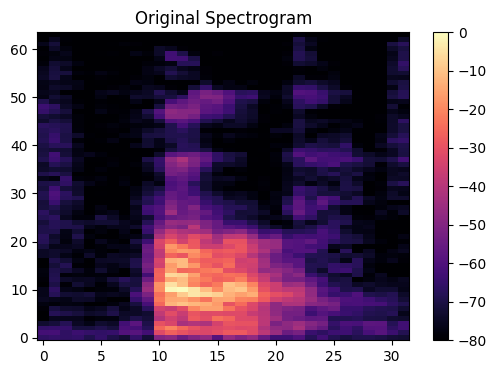

In [115]:
plt.figure(figsize=(6,4))

plt.imshow(
    sample_spec.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma"
)

plt.colorbar()

plt.title("Original Spectrogram")

plt.show()

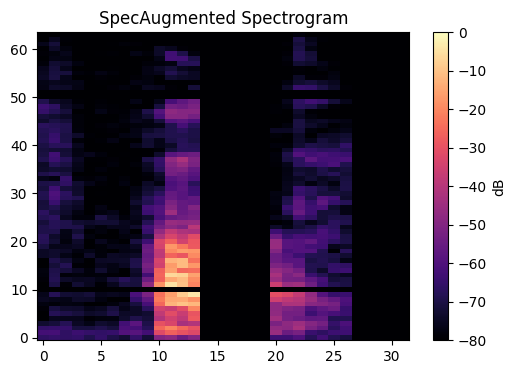

In [116]:
augmented_spec = augment(sample_spec)

plt.figure(figsize=(6,4))

plt.imshow(
    augmented_spec.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=-80,
    vmax=0
)

plt.colorbar(label="dB")
plt.title("SpecAugmented Spectrogram")

plt.show()

In [117]:
sample_spec, _ = train_dataset[0]

aug = augment(sample_spec)

print("Original min:", sample_spec.min().item())
print("Original max:", sample_spec.max().item())

print("Aug min:", aug.min().item())
print("Aug max:", aug.max().item())

changed = (sample_spec != aug).sum().item()

print("Changed values:", changed)
print("Total values:", sample_spec.numel())

Original min: -80.0
Original max: 0.0
Aug min: -80.0
Aug max: 0.0
Changed values: 555
Total values: 2048


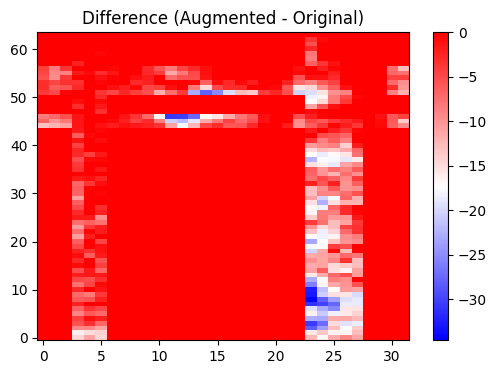

In [118]:
difference = aug - sample_spec

plt.figure(figsize=(6,4))
plt.imshow(
    difference.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="bwr"
)
plt.colorbar()
plt.title("Difference (Augmented - Original)")
plt.show()

In [136]:
from sklearn.model_selection import train_test_split

train_files, temp_files, train_labels, temp_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print(len(train_files))
print(len(val_files))
print(len(test_files))

74080
15874
15875


In [137]:
train_dataset = AudioDataset(
    train_files,
    train_labels,
    preprocessor,
    augment=augment
)

val_dataset = AudioDataset(
    val_files,
    val_labels,
    preprocessor,
    augment=None
)

test_dataset = AudioDataset(
    test_files,
    test_labels,
    preprocessor,
    augment=None
)

In [138]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [139]:
model = AudioCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [140]:
train_losses = []
train_accs = []
val_accs = []

best_val_acc = 0

In [141]:
print(type(labels[0]))
print(labels[:10])

<class 'int'>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [143]:
# ==========================================
# Train CNN with SpecAugment
# ==========================================

train_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_acc = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Train Accuracy      : {train_acc:.2f}%")
    print(f"Validation Accuracy : {val_acc:.2f}%")
    print("-"*60)

    # Save checkpoint after every epoch
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }

    torch.save(
        checkpoint,
        f"../models/checkpoint_epoch_{epoch+1}_with_aug.pth"
    )

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "../models/best_model_with_aug.pth"
        )

        print("✅ Best model saved!")

print("\nTraining Complete.")
print(f"Best Validation Accuracy : {best_val_acc:.2f}%")


Epoch 1/10
Train Loss          : 2.0892
Train Accuracy      : 41.52%
Validation Accuracy : 61.02%
------------------------------------------------------------
✅ Best model saved!

Epoch 2/10
Train Loss          : 1.8525
Train Accuracy      : 47.56%
Validation Accuracy : 64.34%
------------------------------------------------------------
✅ Best model saved!

Epoch 3/10
Train Loss          : 1.6921
Train Accuracy      : 51.88%
Validation Accuracy : 70.20%
------------------------------------------------------------
✅ Best model saved!

Epoch 4/10
Train Loss          : 1.5894
Train Accuracy      : 54.80%
Validation Accuracy : 73.28%
------------------------------------------------------------
✅ Best model saved!

Epoch 5/10
Train Loss          : 1.5094
Train Accuracy      : 56.76%
Validation Accuracy : 76.93%
------------------------------------------------------------
✅ Best model saved!

Epoch 6/10
Train Loss          : 1.4496
Train Accuracy      : 58.18%
Validation Accuracy : 77.47%
-

In [144]:
history = pd.DataFrame({

    "Epoch": range(1, len(train_losses) + 1),

    "Train Loss": train_losses,

    "Train Accuracy": train_accs,

    "Validation Accuracy": val_accs

})

history.to_csv(
    "../outputs/training_curves/training_history_with_aug.csv",
    index=False
)

history.head()

,Epoch,Train Loss,Train Accuracy,Validation Accuracy
0,1,2.089240,41.517279,61.018017
1,2,1.852548,47.564795,64.344211
2,3,1.692142,51.881749,70.196548
3,4,1.589444,54.798866,73.283356
4,5,1.509372,56.756210,76.930830


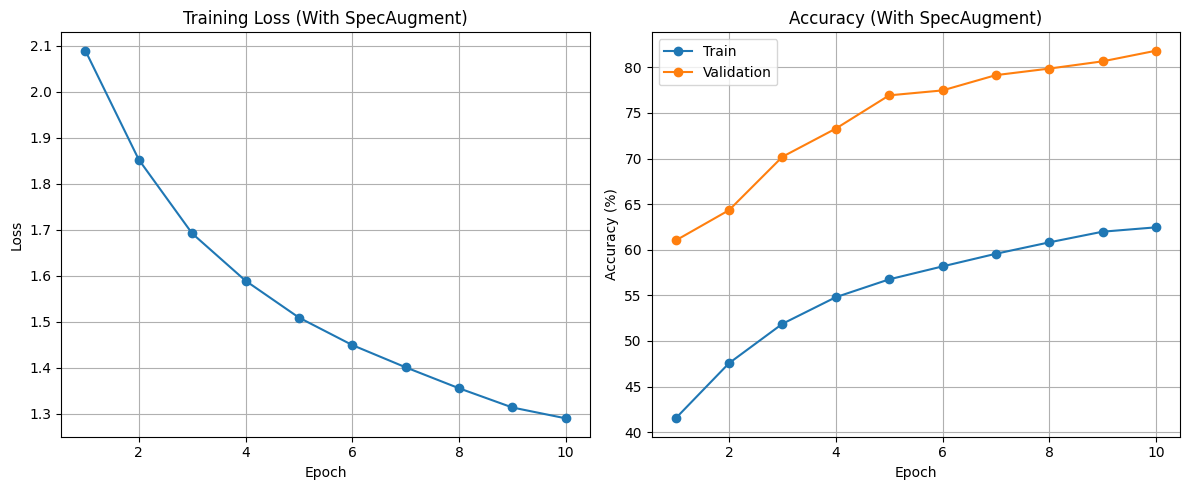

In [145]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["Epoch"], history["Train Loss"], marker="o")
plt.title("Training Loss (With SpecAugment)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history["Epoch"], history["Train Accuracy"], label="Train", marker="o")
plt.plot(history["Epoch"], history["Validation Accuracy"], label="Validation", marker="o")
plt.title("Accuracy (With SpecAugment)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/training_curves/training_curves_with_aug.png"
)

plt.show()

In [146]:
model = AudioCNN(
    num_classes=NUM_CLASSES
).to(device)

model.load_state_dict(
    torch.load(
        "../models/best_model_with_aug.pth",
        map_location=device
    )
)

model.eval()

print("Best SpecAugment model loaded.")

Best SpecAugment model loaded.


In [147]:
all_predictions = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print("Total Test Samples :", len(all_labels))

Total Test Samples : 15875


In [148]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall : {macro_recall:.4f}")
print(f"Macro F1 Score : {macro_f1:.4f}")

Test Accuracy : 81.89%
Macro Precision : 0.8263
Macro Recall : 0.7916
Macro F1 Score : 0.8000


In [149]:
metrics = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ]

})

metrics.to_csv(
    "../outputs/predictions/test_metrics_with_aug.csv",
    index=False
)

metrics

,Metric,Value
0,Accuracy,0.818898
1,Precision,0.826266
2,Recall,0.791588
3,F1 Score,0.800004


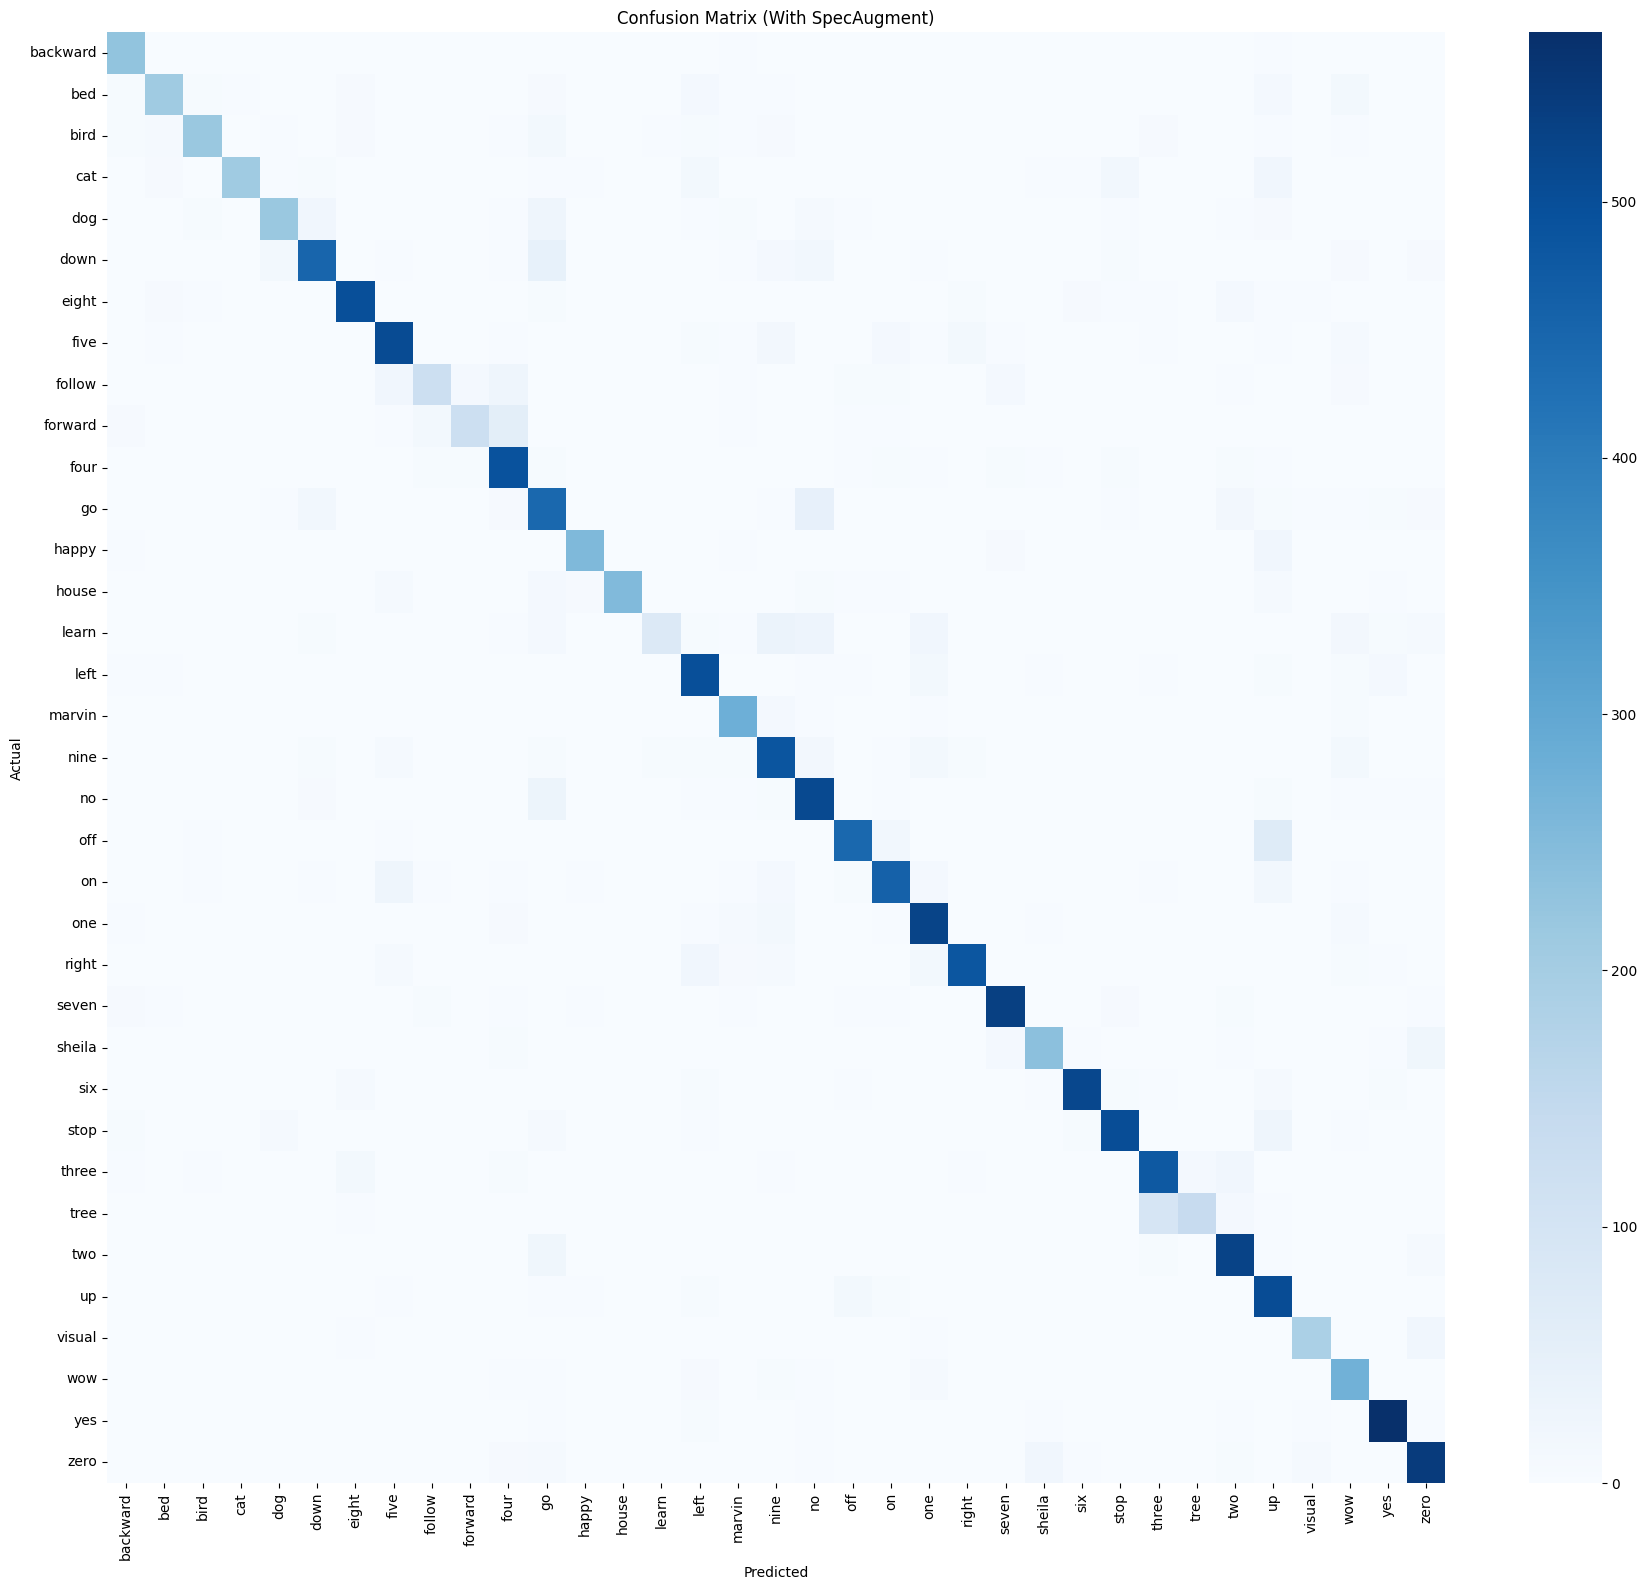

In [150]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(18,16))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix (With SpecAugment)")

plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix/confusion_matrix_with_aug.png"
)

plt.show()

In [151]:
prediction_df = pd.DataFrame({

    "Actual": all_labels,

    "Predicted": all_predictions

})

prediction_df.to_csv(
    "../outputs/predictions/test_predictions_with_aug.csv",
    index=False
)

prediction_df.head()

,Actual,Predicted
0,27,27
1,11,11
2,6,30
3,17,17
4,28,27


In [152]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Without SpecAugment": [
        0.00,   # Replace with Part A Accuracy
        0.00,   # Replace with Part A Precision
        0.00,   # Replace with Part A Recall
        0.00    # Replace with Part A F1
    ],

    "With SpecAugment": [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ]

})

comparison

,Metric,Without SpecAugment,With SpecAugment
0,Accuracy,0.0,0.818898
1,Precision,0.0,0.826266
2,Recall,0.0,0.791588
3,F1 Score,0.0,0.800004
